<a href="https://colab.research.google.com/github/AntonDozhdikov/politpredict/blob/main/mappo_legal_reward_hacking_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ф Colab/Jupyter pipeline: MAPPO, reward hacking, право и институциональные ограничения

Этот блокнот представляет **полный воспроизводимый исследовательский пайплайн** для двух экспериментов на MAPPO:

- **Эксперимент 1:** отсутствие правовых ограничителей, что создает условия для reward hacking и KPI-gaming.
- **Эксперимент 2:** включение аудита, санкций и welfare-constraints как аналога правовых и институциональных механизмов защиты.

Блокнот рассчитан на:
- запуск в **Google Colab**,
- корректное отображение на **GitHub**,
- использование как технического артефакта ,
- генерацию итоговых таблиц и рисунков.

## Что делает этот блокнот

1. Подготавливает окружение для CPU и GPU T4.
2. Генерирует baseline синтетический датасет.
3. Обучает два MAPPO-эксперимента.
4. Выполняет **20 прогонов по разным сидам**.
5. Собирает агрегированные результаты и строит графики.
6. Выполняет **непараметрические тесты различий**.
7. Сохраняет итоговые таблицы, графики и Markdown-отчёт.



In [1]:
# ==========================================================
# 1. Базовые настройки ноутбука
# ==========================================================

import os
import sys
import json
import math
import time
import random
import subprocess
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

from tqdm.auto import tqdm
from IPython.display import display, Markdown, Image

# Настройки отображения для GitHub и Colab:
# - показываем больше строк и колонок,
# - не обрезаем широкий текст,
# - делаем таблицы удобными для чтения.
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 200)

# Глобальные настройки визуализации.
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['savefig.dpi'] = 180

PROJECT_DIR = Path('mappo_legal_project')
ARTIFACTS_DIR = PROJECT_DIR / 'artifacts'
FIG_DIR = ARTIFACTS_DIR / 'figures'
TABLE_DIR = ARTIFACTS_DIR / 'tables'
CKPT_DIR = ARTIFACTS_DIR / 'checkpoints'
for p in [PROJECT_DIR, ARTIFACTS_DIR, FIG_DIR, TABLE_DIR, CKPT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('Рабочая директория:', PROJECT_DIR.resolve())

Рабочая директория: /content/mappo_legal_project


In [2]:
# ==========================================================
# 2. Установка и проверка окружения
# ==========================================================

# В Colab эти установки обычно уже выполнены, но мы оставляем их явно,
# чтобы ноутбук был самодостаточным.

try:
    import scipy
    import torch
except ImportError:
    !pip -q install scipy torch torchvision torchaudio seaborn tqdm
    import scipy
    import torch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Доступное устройство:', DEVICE)
if DEVICE == 'cuda':
    print('Имя GPU:', torch.cuda.get_device_name(0))
else:
    print('Запуск будет выполнен на CPU. Для Colab GPU T4 включается через Runtime -> Change runtime type -> GPU.')

Доступное устройство: cuda
Имя GPU: Tesla T4


In [3]:
# ==========================================================
# 3. Глобальные утилиты
# ==========================================================

from scipy.stats import mannwhitneyu, wilcoxon


def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def moving_average(values: List[float], window: int = 10) -> np.ndarray:
    arr = np.asarray(values, dtype=float)
    if len(arr) == 0:
        return arr
    if len(arr) < window:
        return arr
    kernel = np.ones(window) / window
    valid = np.convolve(arr, kernel, mode='valid')
    prefix = np.array([arr[:i+1].mean() for i in range(window - 1)])
    return np.concatenate([prefix, valid])


def normalize3(a: float, b: float, c: float) -> Tuple[float, float, float]:
    s = a + b + c
    if s <= 0:
        return 1/3, 1/3, 1/3
    return a/s, b/s, c/s


def save_df(df: pd.DataFrame, path: Path, index: bool = False):
    df.to_csv(path, index=index)
    print(f'Сохранено: {path}')

In [4]:
# ==========================================================
# 4. Генератор baseline синтетического датасета
# ==========================================================

# Этот датасет нужен не только как подготовительный артефакт,
# но и как документируемая табличная основа для описания среды.


def generate_baseline_dataset(
    output_dir: Path,
    seed: int = 42,
    n_regions: int = 5,
    episodes_per_mode: int = 40,
    steps: int = 24,
    base_budget: float = 1000.0,
    budget_jitter: float = 100.0,
):
    set_global_seed(seed)
    ensure_dir(output_dir)

    regions = [f'R{i+1}' for i in range(n_regions)]
    rows = []
    summary_rows = []

    for experiment in [1, 2]:
        has_auditor = 1 if experiment == 2 else 0
        constraint_active = 1 if experiment == 2 else 0

        for episode in range(episodes_per_mode):
            B = float(np.random.uniform(base_budget - budget_jitter, base_budget + budget_jitter))
            W = float(np.random.uniform(45.0, 55.0))
            Q = float(np.random.uniform(0.45, 0.60))
            C = float(np.random.uniform(0.20, 0.35))
            I = float(np.random.uniform(0.35, 0.50))
            K = float(np.random.uniform(0.05, 0.12))
            P_built = 0.0
            P_useful = 0.0

            region_state = {}
            for r in regions:
                region_state[r] = {
                    'b_i': 0.0,
                    'p_built_i': 0.0,
                    'p_useful_i': 0.0,
                    'q_i': float(np.random.uniform(0.45, 0.60)),
                    'i_i': float(np.random.uniform(0.30, 0.50)),
                    'c_i': float(np.random.uniform(0.20, 0.35)),
                }

            ep_proxy = 0.0
            ep_true = 0.0
            ep_gap = 0.0
            ep_violation = 0.0
            global_episode_id = episode + (0 if experiment == 1 else episodes_per_mode)

            for step in range(steps):
                alpha = float(np.clip(np.random.normal(0.62 if experiment == 1 else 0.48, 0.06), 0.30, 0.80))
                beta = float(np.clip(np.random.normal(0.26, 0.05), 0.10, 0.45))
                gamma = float(np.clip(1.0 - alpha - beta, 0.08 if experiment == 1 else 0.18, 0.35))
                alpha, beta, gamma = normalize3(alpha, beta, gamma)

                alloc_raw = np.random.dirichlet(np.ones(n_regions) * (1.2 if experiment == 1 else 1.5))
                region_budgets = {r: float(B * alloc_raw[i]) for i, r in enumerate(regions)}

                audited_region = 'none'
                sanction_level = 0.0
                if has_auditor:
                    risks = []
                    for r in regions:
                        rs = region_state[r]
                        risk = 0.4 * rs['c_i'] + 0.4 * K + 0.2 * max(0.0, rs['p_built_i'] - rs['p_useful_i']) / (1.0 + rs['p_built_i'])
                        risks.append(risk)
                    audited_region = regions[int(np.argmax(risks))]
                    sanction_level = float(np.clip(np.random.normal(0.75, 0.10), 0.50, 0.95))

                fc_proxy_reward = 0.0
                step_system_violation = 0.0
                step_system_gap = 0.0
                region_records = []

                for r in regions:
                    rs = region_state[r]
                    b_i = region_budgets[r]
                    rs['b_i'] = b_i

                    pressure = 0.55 * alpha + 0.25 * C + 0.20 * K
                    if experiment == 1:
                        fake_share = float(np.clip(np.random.beta(2 + 4 * pressure, 3), 0.05, 0.75))
                        useful_share = float(np.clip(np.random.beta(2, 3 + 4 * pressure), 0.05, 0.65))
                    else:
                        fake_share = float(np.clip(np.random.beta(1.5 + 2 * pressure, 5), 0.01, 0.45))
                        useful_share = float(np.clip(np.random.beta(3.5, 2.5 + 1.5 * pressure), 0.20, 0.80))
                    cheap_share = max(0.0, 1.0 - useful_share - fake_share)
                    useful_share, fake_share, cheap_share = normalize3(useful_share, fake_share, cheap_share)

                    report_mode = int(np.random.choice([0, 1, 2], p=[0.35, 0.45, 0.20] if experiment == 1 else [0.70, 0.20, 0.10]))

                    useful_projects = useful_share * b_i / 22.0
                    cheap_projects = cheap_share * b_i / 12.0
                    fake_projects = fake_share * b_i / 8.0

                    actual_useful = useful_projects + 0.35 * cheap_projects
                    reported_built = useful_projects + cheap_projects + fake_projects
                    quality_gain = 0.0035 * useful_projects + 0.0010 * cheap_projects - 0.0020 * fake_projects
                    infra_gain = 0.0040 * actual_useful - 0.0012 * fake_projects
                    diss_change = -0.0030 * actual_useful + 0.0025 * fake_projects + 0.0015 * cheap_projects

                    if report_mode == 1:
                        reported_built *= 1.20
                    elif report_mode == 2:
                        quality_gain += 0.01

                    violation = max(0.0, reported_built - actual_useful) * 0.12
                    if report_mode == 2:
                        violation += 0.10

                    audited = int(r == audited_region)
                    expected_detection = 0.0
                    if has_auditor and audited:
                        expected_detection = sanction_level * min(1.0, 0.4 + violation)
                    legal_penalty = expected_detection * (5.0 + 8.0 * violation)

                    rs['p_built_i'] += reported_built
                    rs['p_useful_i'] += actual_useful
                    rs['q_i'] = float(np.clip(rs['q_i'] + quality_gain - 0.015 * violation, 0.10, 1.00))
                    rs['i_i'] = float(np.clip(rs['i_i'] + infra_gain, 0.0, 2.0))
                    rs['c_i'] = float(np.clip(rs['c_i'] + diss_change + 0.010 * violation, 0.0, 1.5))

                    spent_ratio = b_i / B if B > 0 else 0.0
                    rating = 0.7 * min(1.0, reported_built / 18.0) + 0.3 * max(0.0, 1.0 - rs['c_i'])
                    reward_proxy = 4.0 * (alpha * reported_built + beta * 10.0 * spent_ratio + gamma * 8.0 * rating) - legal_penalty
                    welfare_true = 3.2 * actual_useful + 6.0 * rs['q_i'] + 5.0 * rs['i_i'] - 5.5 * rs['c_i']
                    gap_delta = reward_proxy - 0.75 * welfare_true

                    P_built += reported_built
                    P_useful += actual_useful
                    step_system_violation += violation
                    step_system_gap += gap_delta
                    fc_proxy_reward += reward_proxy

                    region_records.append({
                        'episode': global_episode_id,
                        'step': step,
                        'experiment': experiment,
                        'has_auditor': has_auditor,
                        'constraint_active': constraint_active,
                        'agent_id': r,
                        'agent_type': 'region',
                        'region_id': r,
                        'W': np.nan,
                        'B': B,
                        'P_built': np.nan,
                        'P_useful': np.nan,
                        'Q': np.nan,
                        'C': np.nan,
                        'I': np.nan,
                        'K': np.nan,
                        'b_i': round(b_i, 4),
                        'p_built_i': round(rs['p_built_i'], 4),
                        'p_useful_i': round(rs['p_useful_i'], 4),
                        'q_i': round(rs['q_i'], 4),
                        'i_i': round(rs['i_i'], 4),
                        'c_i': round(rs['c_i'], 4),
                        'a_alloc_i': np.nan,
                        'a_KPI_alpha': np.nan,
                        'a_KPI_beta': np.nan,
                        'a_KPI_gamma': np.nan,
                        'a_proj_useful_share': round(useful_share, 4),
                        'a_proj_fake_share': round(fake_share, 4),
                        'a_proj_cheap_share': round(cheap_share, 4),
                        'a_report_mode': report_mode,
                        'a_audit_target': audited_region if has_auditor else 'none',
                        'a_sanction_level': round(sanction_level if audited else 0.0, 4),
                        'reward_proxy': round(reward_proxy, 4),
                        'welfare_true': round(welfare_true, 4),
                        'violation': round(violation, 4),
                        'gap_delta': round(gap_delta, 4),
                    })

                avg_q = float(np.mean([region_state[r]['q_i'] for r in regions]))
                avg_c = float(np.mean([region_state[r]['c_i'] for r in regions]))
                avg_i = float(np.mean([region_state[r]['i_i'] for r in regions]))
                K = float(np.clip(0.90 * K + 0.03 * step_system_violation / n_regions + (0.01 if experiment == 1 else -0.005), 0.0, 2.0))
                Q, C, I = avg_q, avg_c, avg_i
                W = float(0.30 * P_useful + 10.0 * Q + 8.0 * I - 9.0 * C - 2.5 * K)

                rows.append({
                    'episode': global_episode_id,
                    'step': step,
                    'experiment': experiment,
                    'has_auditor': has_auditor,
                    'constraint_active': constraint_active,
                    'agent_id': 'FC',
                    'agent_type': 'federal_center',
                    'region_id': 'NA',
                    'W': round(W, 4),
                    'B': round(B, 4),
                    'P_built': round(P_built, 4),
                    'P_useful': round(P_useful, 4),
                    'Q': round(Q, 4),
                    'C': round(C, 4),
                    'I': round(I, 4),
                    'K': round(K, 4),
                    'b_i': np.nan,
                    'p_built_i': np.nan,
                    'p_useful_i': np.nan,
                    'q_i': np.nan,
                    'i_i': np.nan,
                    'c_i': np.nan,
                    'a_alloc_i': round(float(np.mean(list(region_budgets.values())) / B), 4),
                    'a_KPI_alpha': round(alpha, 4),
                    'a_KPI_beta': round(beta, 4),
                    'a_KPI_gamma': round(gamma, 4),
                    'a_proj_useful_share': np.nan,
                    'a_proj_fake_share': np.nan,
                    'a_proj_cheap_share': np.nan,
                    'a_report_mode': np.nan,
                    'a_audit_target': audited_region if has_auditor else 'none',
                    'a_sanction_level': round(sanction_level, 4),
                    'reward_proxy': round(fc_proxy_reward / n_regions, 4),
                    'welfare_true': round(W, 4),
                    'violation': round(step_system_violation, 4),
                    'gap_delta': round((fc_proxy_reward / n_regions) - 0.75 * W, 4),
                })
                rows.extend(region_records)

                if has_auditor:
                    au_reward = -step_system_violation - 0.8 * sanction_level
                    rows.append({
                        'episode': global_episode_id,
                        'step': step,
                        'experiment': experiment,
                        'has_auditor': has_auditor,
                        'constraint_active': constraint_active,
                        'agent_id': 'AU',
                        'agent_type': 'auditor',
                        'region_id': 'NA',
                        'W': round(W, 4),
                        'B': round(B, 4),
                        'P_built': round(P_built, 4),
                        'P_useful': round(P_useful, 4),
                        'Q': round(Q, 4),
                        'C': round(C, 4),
                        'I': round(I, 4),
                        'K': round(K, 4),
                        'b_i': np.nan,
                        'p_built_i': np.nan,
                        'p_useful_i': np.nan,
                        'q_i': np.nan,
                        'i_i': np.nan,
                        'c_i': np.nan,
                        'a_alloc_i': np.nan,
                        'a_KPI_alpha': np.nan,
                        'a_KPI_beta': np.nan,
                        'a_KPI_gamma': np.nan,
                        'a_proj_useful_share': np.nan,
                        'a_proj_fake_share': np.nan,
                        'a_proj_cheap_share': np.nan,
                        'a_report_mode': np.nan,
                        'a_audit_target': audited_region,
                        'a_sanction_level': round(sanction_level, 4),
                        'reward_proxy': round(au_reward, 4),
                        'welfare_true': round(-step_system_violation, 4),
                        'violation': round(step_system_violation, 4),
                        'gap_delta': round(au_reward + 0.75 * step_system_violation, 4),
                    })

                ep_proxy += fc_proxy_reward / n_regions
                ep_true += W
                ep_gap += step_system_gap / n_regions
                ep_violation += step_system_violation

            summary_rows.append({
                'episode': global_episode_id,
                'experiment': experiment,
                'has_auditor': has_auditor,
                'constraint_active': constraint_active,
                'mean_fc_proxy_reward': round(ep_proxy / steps, 4),
                'mean_system_welfare': round(ep_true / steps, 4),
                'mean_gap_delta': round(ep_gap / steps, 4),
                'mean_violation': round(ep_violation / steps, 4),
            })

    df = pd.DataFrame(rows)
    summary = pd.DataFrame(summary_rows)
    dataset_path = output_dir / 'baseline_dataset.csv'
    summary_path = output_dir / 'baseline_summary.csv'
    df.to_csv(dataset_path, index=False)
    summary.to_csv(summary_path, index=False)
    return df, summary, dataset_path, summary_path

In [5]:
# ==========================================================
# 5. MARL-среда и конфигурации эксперимента
# ==========================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical


@dataclass
class EnvConfig:
    seed: int = 42
    n_regions: int = 5
    max_steps: int = 24
    base_budget: float = 1000.0
    budget_jitter: float = 100.0
    use_protection: bool = False

    welfare_useful_coef: float = 3.2
    welfare_quality_coef: float = 6.0
    welfare_infra_coef: float = 5.0
    welfare_dissat_coef: float = 5.5

    global_welfare_useful_coef: float = 0.30
    global_welfare_quality_coef: float = 10.0
    global_welfare_infra_coef: float = 8.0
    global_welfare_dissat_coef: float = 9.0
    global_welfare_corruption_coef: float = 2.5

    reward_scale: float = 4.0
    detection_base: float = 0.4
    penalty_base: float = 5.0
    penalty_violation_coef: float = 8.0
    gap_welfare_weight: float = 0.75


class GovernanceMARLEnv:
    def __init__(self, cfg: EnvConfig):
        self.cfg = cfg
        self.rng = np.random.default_rng(cfg.seed)
        self.n_agents = cfg.n_regions
        self.agent_ids = [f'R{i+1}' for i in range(self.n_agents)]
        self.local_obs_dim = 16
        self.global_state_dim = 12 + self.n_agents * 5
        self.action_dim = 5
        self.reset()

    def _allocate_budget(self):
        weights = self.rng.dirichlet(np.ones(self.n_agents) * (1.2 if not self.cfg.use_protection else 1.5))
        return {r: float(self.B * weights[i]) for i, r in enumerate(self.agent_ids)}

    def _sample_initial_state(self):
        self.t = 0
        self.B = float(self.rng.uniform(self.cfg.base_budget - self.cfg.budget_jitter, self.cfg.base_budget + self.cfg.budget_jitter))
        self.W = float(self.rng.uniform(45.0, 55.0))
        self.Q = float(self.rng.uniform(0.45, 0.60))
        self.C = float(self.rng.uniform(0.20, 0.35))
        self.I = float(self.rng.uniform(0.35, 0.50))
        self.K = float(self.rng.uniform(0.05, 0.12))
        self.P_built = 0.0
        self.P_useful = 0.0

        self.alpha = 0.62 if not self.cfg.use_protection else 0.48
        self.beta = 0.26
        self.gamma = 1.0 - self.alpha - self.beta
        self.alpha, self.beta, self.gamma = normalize3(self.alpha, self.beta, self.gamma)

        self.regions = {}
        for r in self.agent_ids:
            self.regions[r] = {
                'budget': 0.0,
                'p_built': 0.0,
                'p_useful': 0.0,
                'quality': float(self.rng.uniform(0.45, 0.60)),
                'infra': float(self.rng.uniform(0.30, 0.50)),
                'dissat': float(self.rng.uniform(0.20, 0.35)),
                'last_violation': 0.0,
                'last_proxy_reward': 0.0,
                'last_true_welfare': 0.0,
                'last_gap': 0.0,
            }
        self.current_allocations = self._allocate_budget()
        self.current_audited_region = 'none'
        self.current_sanction = 0.0

    def reset(self):
        self._sample_initial_state()
        return self._get_local_obs(), self._get_global_state()

    def _choose_kpi_weights(self):
        a_mean = 0.62 if not self.cfg.use_protection else 0.48
        self.alpha = float(np.clip(self.rng.normal(a_mean, 0.05), 0.30, 0.80))
        self.beta = float(np.clip(self.rng.normal(0.26, 0.04), 0.10, 0.45))
        g_floor = 0.08 if not self.cfg.use_protection else 0.18
        self.gamma = float(np.clip(1.0 - self.alpha - self.beta, g_floor, 0.35))
        self.alpha, self.beta, self.gamma = normalize3(self.alpha, self.beta, self.gamma)

    def _select_audited_region(self):
        if not self.cfg.use_protection:
            self.current_audited_region = 'none'
            self.current_sanction = 0.0
            return
        risks = []
        for r in self.agent_ids:
            rs = self.regions[r]
            risk = 0.4 * rs['dissat'] + 0.4 * self.K + 0.2 * max(0.0, rs['p_built'] - rs['p_useful']) / (1.0 + rs['p_built'])
            risks.append(risk)
        self.current_audited_region = self.agent_ids[int(np.argmax(risks))]
        self.current_sanction = float(np.clip(self.rng.normal(0.75, 0.10), 0.50, 0.95))

    def _decode_action(self, action: int):
        if action == 0:
            return 0.60, 0.10, 0.30, 0, 0.0
        if action == 1:
            return 0.15, 0.55, 0.30, 1, 0.0
        if action == 2:
            return 0.12, 0.58, 0.30, 2, 0.0
        if action == 3:
            return 0.38, 0.22, 0.40, 0, 0.0
        return 0.55, 0.05, 0.40, 0, 0.15

    def _get_local_obs(self):
        obs = []
        for r in self.agent_ids:
            rs = self.regions[r]
            obs.append([
                self.t / self.cfg.max_steps,
                self.B / 1500.0,
                self.alpha,
                self.beta,
                self.gamma,
                self.W / 200.0,
                self.Q,
                self.C,
                self.I,
                self.K,
                rs['budget'] / 500.0,
                rs['p_built'] / 200.0,
                rs['p_useful'] / 200.0,
                rs['quality'],
                rs['infra'],
                rs['dissat'],
            ])
        return np.asarray(obs, dtype=np.float32)

    def _get_global_state(self):
        state = [
            self.t / self.cfg.max_steps,
            self.B / 1500.0,
            self.W / 200.0,
            self.P_built / 1000.0,
            self.P_useful / 1000.0,
            self.Q,
            self.C,
            self.I,
            self.K,
            self.alpha,
            self.beta,
            self.gamma,
        ]
        for r in self.agent_ids:
            rs = self.regions[r]
            state.extend([
                rs['budget'] / 500.0,
                rs['p_built'] / 200.0,
                rs['p_useful'] / 200.0,
                rs['quality'],
                rs['dissat'],
            ])
        return np.asarray(state, dtype=np.float32)

    def step(self, actions: np.ndarray):
        self.t += 1
        self._choose_kpi_weights()
        self.current_allocations = self._allocate_budget()
        self._select_audited_region()

        rewards = np.zeros(self.n_agents, dtype=np.float32)
        done = self.t >= self.cfg.max_steps

        total_violation = 0.0
        total_gap = 0.0
        total_proxy = 0.0
        total_true = 0.0
        step_records = []

        for i, r in enumerate(self.agent_ids):
            rs = self.regions[r]
            rs['budget'] = self.current_allocations[r]

            useful_share, fake_share, cheap_share, report_mode, legalist_bonus = self._decode_action(int(actions[i]))
            if self.cfg.use_protection:
                useful_share = min(0.85, useful_share + 0.08)
                fake_share = max(0.0, fake_share - 0.10)
                cheap_share = max(0.05, cheap_share + 0.02)
                useful_share, fake_share, cheap_share = normalize3(useful_share, fake_share, cheap_share)

            b_i = rs['budget']
            useful_projects = useful_share * b_i / 22.0
            cheap_projects = cheap_share * b_i / 12.0
            fake_projects = fake_share * b_i / 8.0

            actual_useful = useful_projects + 0.35 * cheap_projects
            reported_built = useful_projects + cheap_projects + fake_projects

            quality_gain = 0.0035 * useful_projects + 0.0010 * cheap_projects - 0.0020 * fake_projects + legalist_bonus * 0.010
            infra_gain = 0.0040 * actual_useful - 0.0012 * fake_projects + legalist_bonus * 0.004
            diss_change = -0.0030 * actual_useful + 0.0025 * fake_projects + 0.0015 * cheap_projects - legalist_bonus * 0.003

            if report_mode == 1:
                reported_built *= 1.20
            elif report_mode == 2:
                quality_gain += 0.01

            violation = max(0.0, reported_built - actual_useful) * 0.12
            if report_mode == 2:
                violation += 0.10

            audited = int(self.cfg.use_protection and r == self.current_audited_region)
            expected_detection = 0.0
            if audited:
                expected_detection = self.current_sanction * min(1.0, self.cfg.detection_base + violation)
            legal_penalty = expected_detection * (self.cfg.penalty_base + self.cfg.penalty_violation_coef * violation)

            constraint_penalty = 0.0
            if self.cfg.use_protection:
                projected_true = (
                    self.cfg.welfare_useful_coef * actual_useful
                    + self.cfg.welfare_quality_coef * max(0.0, rs['quality'] + quality_gain)
                    + self.cfg.welfare_infra_coef * max(0.0, rs['infra'] + infra_gain)
                    - self.cfg.welfare_dissat_coef * max(0.0, rs['dissat'] + diss_change)
                )
                threshold = 10.0
                constraint_penalty = max(0.0, threshold - projected_true) * 0.8

            rs['p_built'] += reported_built
            rs['p_useful'] += actual_useful
            rs['quality'] = float(np.clip(rs['quality'] + quality_gain - 0.015 * violation, 0.10, 1.00))
            rs['infra'] = float(np.clip(rs['infra'] + infra_gain, 0.0, 2.0))
            rs['dissat'] = float(np.clip(rs['dissat'] + diss_change + 0.010 * violation, 0.0, 1.5))

            spent_ratio = b_i / self.B if self.B > 0 else 0.0
            rating = 0.7 * min(1.0, reported_built / 18.0) + 0.3 * max(0.0, 1.0 - rs['dissat'])
            proxy_reward = self.cfg.reward_scale * (
                self.alpha * reported_built + self.beta * 10.0 * spent_ratio + self.gamma * 8.0 * rating
            ) - legal_penalty - constraint_penalty

            true_welfare = (
                self.cfg.welfare_useful_coef * actual_useful
                + self.cfg.welfare_quality_coef * rs['quality']
                + self.cfg.welfare_infra_coef * rs['infra']
                - self.cfg.welfare_dissat_coef * rs['dissat']
            )
            gap_delta = proxy_reward - self.cfg.gap_welfare_weight * true_welfare

            rs['last_violation'] = violation
            rs['last_proxy_reward'] = proxy_reward
            rs['last_true_welfare'] = true_welfare
            rs['last_gap'] = gap_delta

            rewards[i] = proxy_reward
            total_violation += violation
            total_gap += gap_delta
            total_proxy += proxy_reward
            total_true += true_welfare

            self.P_built += reported_built
            self.P_useful += actual_useful

            step_records.append({
                'agent_id': r,
                'allocated_budget': b_i,
                'reported_built_increment': reported_built,
                'actual_useful_increment': actual_useful,
                'violation': violation,
                'proxy_reward': proxy_reward,
                'true_welfare': true_welfare,
                'gap_delta': gap_delta,
                'report_mode': report_mode,
                'audited': audited,
                'legal_penalty': legal_penalty,
                'constraint_penalty': constraint_penalty,
            })

        self.Q = float(np.mean([self.regions[r]['quality'] for r in self.agent_ids]))
        self.C = float(np.mean([self.regions[r]['dissat'] for r in self.agent_ids]))
        self.I = float(np.mean([self.regions[r]['infra'] for r in self.agent_ids]))
        self.K = float(np.clip(0.90 * self.K + 0.03 * total_violation / self.n_agents + (0.01 if not self.cfg.use_protection else -0.005), 0.0, 2.0))
        self.W = float(
            self.cfg.global_welfare_useful_coef * self.P_useful
            + self.cfg.global_welfare_quality_coef * self.Q
            + self.cfg.global_welfare_infra_coef * self.I
            - self.cfg.global_welfare_dissat_coef * self.C
            - self.cfg.global_welfare_corruption_coef * self.K
        )

        info = {
            'global_welfare': self.W,
            'reported_output': self.P_built,
            'useful_output': self.P_useful,
            'quality_index': self.Q,
            'public_dissatisfaction': self.C,
            'infrastructure_index': self.I,
            'corruption_index': self.K,
            'system_violation': total_violation,
            'system_gap': total_gap / self.n_agents,
            'mean_proxy_reward': total_proxy / self.n_agents,
            'mean_true_welfare': total_true / self.n_agents,
            'reward_hacking_index': (self.P_built - self.P_useful) / max(1.0, self.P_built),
            'audited_region': self.current_audited_region,
            'sanction_level': self.current_sanction,
            'step_records': step_records,
        }
        return self._get_local_obs(), self._get_global_state(), rewards, done, info

In [6]:
# ==========================================================
# 6. MAPPO: сети, буфер, GAE и обучение
# ==========================================================

class ActorNet(nn.Module):
    def __init__(self, obs_dim: int, action_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, obs):
        return self.net(obs)


class CriticNet(nn.Module):
    def __init__(self, global_state_dim: int, hidden_dim: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(global_state_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, state):
        return self.net(state)


class RolloutBuffer:
    def __init__(self):
        self.obs = []
        self.global_states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.dones = []
        self.values = []
        self.infos = []

    def add(self, obs, global_state, actions, log_probs, rewards, done, value, info):
        self.obs.append(np.array(obs, dtype=np.float32))
        self.global_states.append(np.array(global_state, dtype=np.float32))
        self.actions.append(np.array(actions, dtype=np.int64))
        self.log_probs.append(np.array(log_probs, dtype=np.float32))
        self.rewards.append(np.array(rewards, dtype=np.float32))
        self.dones.append(float(done))
        self.values.append(float(value))
        self.infos.append(info)


@dataclass
class TrainConfig:
    seed: int = 42
    device: str = DEVICE
    n_episodes: int = 120
    gamma: float = 0.99
    gae_lambda: float = 0.95
    clip_coef: float = 0.2
    entropy_coef: float = 0.01
    value_coef: float = 0.5
    max_grad_norm: float = 0.5
    actor_lr: float = 3e-4
    critic_lr: float = 3e-4
    update_epochs: int = 8
    minibatch_size: int = 64
    hidden_dim_actor: int = 128
    hidden_dim_critic: int = 256


def compute_gae(rewards, values, dones, last_value, gamma, gae_lambda):
    T = len(rewards)
    advantages = np.zeros((T,), dtype=np.float32)
    lastgaelam = 0.0
    for t in reversed(range(T)):
        if t == T - 1:
            nextnonterminal = 1.0 - dones[t]
            nextvalues = last_value
        else:
            nextnonterminal = 1.0 - dones[t + 1]
            nextvalues = values[t + 1]
        reward_t = rewards[t].mean()
        delta = reward_t + gamma * nextvalues * nextnonterminal - values[t]
        lastgaelam = delta + gamma * gae_lambda * nextnonterminal * lastgaelam
        advantages[t] = lastgaelam
    returns = advantages + values
    return advantages, returns


class MAPPOTrainer:
    def __init__(self, env_cfg: EnvConfig, train_cfg: TrainConfig, run_dir: Path, run_name: str):
        self.env_cfg = env_cfg
        self.train_cfg = train_cfg
        self.run_dir = run_dir
        self.run_name = run_name
        ensure_dir(run_dir)
        ensure_dir(run_dir / 'figures')
        ensure_dir(run_dir / 'tables')
        ensure_dir(run_dir / 'checkpoints')

        set_global_seed(train_cfg.seed)
        self.device = torch.device(train_cfg.device)
        self.env = GovernanceMARLEnv(env_cfg)
        self.n_agents = self.env.n_agents

        self.actor = ActorNet(self.env.local_obs_dim, self.env.action_dim, train_cfg.hidden_dim_actor).to(self.device)
        self.critic = CriticNet(self.env.global_state_dim, train_cfg.hidden_dim_critic).to(self.device)
        self.actor_optim = optim.Adam(self.actor.parameters(), lr=train_cfg.actor_lr)
        self.critic_optim = optim.Adam(self.critic.parameters(), lr=train_cfg.critic_lr)
        self.history = []

    def select_actions(self, obs):
        obs_t = torch.tensor(obs, dtype=torch.float32, device=self.device)
        logits = self.actor(obs_t)
        dist = Categorical(logits=logits)
        actions = dist.sample()
        log_probs = dist.log_prob(actions)
        return actions.detach().cpu().numpy(), log_probs.detach().cpu().numpy()

    def evaluate_actions(self, obs, actions):
        logits = self.actor(obs)
        dist = Categorical(logits=logits)
        log_probs = dist.log_prob(actions)
        entropy = dist.entropy()
        return log_probs, entropy

    def collect_episode(self):
        buffer = RolloutBuffer()
        obs, global_state = self.env.reset()
        episode_reward = np.zeros(self.n_agents, dtype=np.float32)
        start = time.perf_counter()

        for _ in range(self.env_cfg.max_steps):
            state_t = torch.tensor(global_state, dtype=torch.float32, device=self.device).unsqueeze(0)
            value = self.critic(state_t).item()
            actions, log_probs = self.select_actions(obs)
            next_obs, next_global_state, rewards, done, info = self.env.step(actions)
            buffer.add(obs, global_state, actions, log_probs, rewards, done, value, info)
            episode_reward += rewards
            obs = next_obs
            global_state = next_global_state
            if done:
                break

        last_value = self.critic(torch.tensor(global_state, dtype=torch.float32, device=self.device).unsqueeze(0)).item()
        elapsed = time.perf_counter() - start
        final_info = buffer.infos[-1]

        metrics = {
            'episode_return_mean': float(episode_reward.mean()),
            'episode_return_total': float(episode_reward.sum()),
            'global_welfare': float(final_info['global_welfare']),
            'reward_hacking_index': float(final_info['reward_hacking_index']),
            'system_gap': float(final_info['system_gap']),
            'system_violation': float(final_info['system_violation']),
            'reported_output': float(final_info['reported_output']),
            'useful_output': float(final_info['useful_output']),
            'quality_index': float(final_info['quality_index']),
            'public_dissatisfaction': float(final_info['public_dissatisfaction']),
            'infrastructure_index': float(final_info['infrastructure_index']),
            'corruption_index': float(final_info['corruption_index']),
            'mean_proxy_reward': float(final_info['mean_proxy_reward']),
            'mean_true_welfare': float(final_info['mean_true_welfare']),
            'collection_seconds': elapsed,
            'last_value': float(last_value),
        }
        return buffer, metrics, last_value

    def update(self, buffer, last_value):
        obs = np.asarray(buffer.obs, dtype=np.float32)
        global_states = np.asarray(buffer.global_states, dtype=np.float32)
        actions = np.asarray(buffer.actions, dtype=np.int64)
        old_log_probs = np.asarray(buffer.log_probs, dtype=np.float32)
        rewards = np.asarray(buffer.rewards, dtype=np.float32)
        dones = np.asarray(buffer.dones, dtype=np.float32)
        values = np.asarray(buffer.values, dtype=np.float32)

        advantages, returns = compute_gae(rewards, values, dones, last_value, self.train_cfg.gamma, self.train_cfg.gae_lambda)

        T, A, O = obs.shape
        obs_flat = torch.tensor(obs.reshape(T * A, O), dtype=torch.float32, device=self.device)
        actions_flat = torch.tensor(actions.reshape(T * A), dtype=torch.int64, device=self.device)
        old_log_probs_flat = torch.tensor(old_log_probs.reshape(T * A), dtype=torch.float32, device=self.device)

        adv_agents = np.repeat(advantages[:, None], A, axis=1).reshape(T * A)
        ret_agents = np.repeat(returns[:, None], A, axis=1).reshape(T * A)
        state_repeat = np.repeat(global_states[:, None, :], A, axis=1).reshape(T * A, global_states.shape[-1])

        advantages_t = torch.tensor(adv_agents, dtype=torch.float32, device=self.device)
        returns_t = torch.tensor(ret_agents, dtype=torch.float32, device=self.device)
        states_t = torch.tensor(state_repeat, dtype=torch.float32, device=self.device)
        advantages_t = (advantages_t - advantages_t.mean()) / (advantages_t.std() + 1e-8)

        batch_size = T * A
        indices = np.arange(batch_size)
        actor_losses, critic_losses, entropies, approx_kls, clipfracs = [], [], [], [], []

        for _ in range(self.train_cfg.update_epochs):
            np.random.shuffle(indices)
            for start in range(0, batch_size, self.train_cfg.minibatch_size):
                mb_idx = indices[start:start + self.train_cfg.minibatch_size]
                mb_obs = obs_flat[mb_idx]
                mb_actions = actions_flat[mb_idx]
                mb_old_logp = old_log_probs_flat[mb_idx]
                mb_adv = advantages_t[mb_idx]
                mb_returns = returns_t[mb_idx]
                mb_states = states_t[mb_idx]

                new_logp, entropy = self.evaluate_actions(mb_obs, mb_actions)
                ratio = (new_logp - mb_old_logp).exp()
                pg_loss1 = -mb_adv * ratio
                pg_loss2 = -mb_adv * torch.clamp(ratio, 1.0 - self.train_cfg.clip_coef, 1.0 + self.train_cfg.clip_coef)
                actor_loss = torch.max(pg_loss1, pg_loss2).mean()

                values_pred = self.critic(mb_states).squeeze(-1)
                critic_loss = ((values_pred - mb_returns) ** 2).mean()
                entropy_loss = entropy.mean()
                loss = actor_loss + self.train_cfg.value_coef * critic_loss - self.train_cfg.entropy_coef * entropy_loss

                self.actor_optim.zero_grad()
                self.critic_optim.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.actor.parameters(), self.train_cfg.max_grad_norm)
                nn.utils.clip_grad_norm_(self.critic.parameters(), self.train_cfg.max_grad_norm)
                self.actor_optim.step()
                self.critic_optim.step()

                with torch.no_grad():
                    approx_kl = (mb_old_logp - new_logp).mean().abs().item()
                    clipfrac = ((ratio - 1.0).abs() > self.train_cfg.clip_coef).float().mean().item()
                    actor_losses.append(actor_loss.item())
                    critic_losses.append(critic_loss.item())
                    entropies.append(entropy_loss.item())
                    approx_kls.append(approx_kl)
                    clipfracs.append(clipfrac)

        return {
            'actor_loss': float(np.mean(actor_losses)),
            'critic_loss': float(np.mean(critic_losses)),
            'entropy': float(np.mean(entropies)),
            'approx_kl': float(np.mean(approx_kls)),
            'clipfrac': float(np.mean(clipfracs)),
            'advantage_mean': float(np.mean(advantages)),
            'return_mean': float(np.mean(returns)),
        }

    def train(self):
        total_start = time.perf_counter()
        pbar = tqdm(range(1, self.train_cfg.n_episodes + 1), desc=f'{self.run_name}: обучение')
        best_welfare = -1e18

        for episode in pbar:
            ep_start = time.perf_counter()
            buffer, ep_metrics, last_value = self.collect_episode()
            update_metrics = self.update(buffer, last_value)
            total_episode_time = time.perf_counter() - ep_start

            row = {
                'episode': episode,
                'experiment': 2 if self.env_cfg.use_protection else 1,
                'protection_enabled': int(self.env_cfg.use_protection),
                **ep_metrics,
                **update_metrics,
                'episode_seconds_total': total_episode_time,
            }
            self.history.append(row)
            df_hist = pd.DataFrame(self.history)

            if row['global_welfare'] > best_welfare:
                best_welfare = row['global_welfare']
                torch.save({
                    'actor_state_dict': self.actor.state_dict(),
                    'critic_state_dict': self.critic.state_dict(),
                    'env_config': asdict(self.env_cfg),
                    'train_config': asdict(self.train_cfg),
                    'best_welfare': best_welfare,
                }, self.run_dir / 'checkpoints' / 'best_model.pt')

            if episode % 20 == 0 or episode == self.train_cfg.n_episodes:
                df_hist.to_csv(self.run_dir / 'tables' / 'training_history.csv', index=False)

            pbar.set_postfix({
                'ret': f"{row['episode_return_mean']:.2f}",
                'welfare': f"{row['global_welfare']:.2f}",
                'hack': f"{row['reward_hacking_index']:.3f}",
                'gap': f"{row['system_gap']:.2f}",
                'time_s': f"{row['episode_seconds_total']:.2f}",
            })

        total_seconds = time.perf_counter() - total_start
        df_hist = pd.DataFrame(self.history)
        df_hist['training_total_seconds'] = total_seconds
        df_hist.to_csv(self.run_dir / 'tables' / 'training_history.csv', index=False)
        return df_hist

In [7]:
# ==========================================================
# 7. Визуализация и итоговые таблицы
# ==========================================================

def save_line_plot(df1, df2, metric, ylabel, title, save_path):
    plt.figure(figsize=(12, 6))
    x1, y1 = df1['episode'].values, df1[metric].values
    x2, y2 = df2['episode'].values, df2[metric].values

    plt.plot(x1, y1, alpha=0.22, linewidth=1.1, label='Эксперимент 1: сырые значения', color='#b22222')
    plt.plot(x1, moving_average(y1, 10), linewidth=2.6, label='Эксперимент 1: сглаженная кривая', color='#8b0000')
    plt.plot(x2, y2, alpha=0.22, linewidth=1.1, label='Эксперимент 2: сырые значения', color='#1f77b4')
    plt.plot(x2, moving_average(y2, 10), linewidth=2.6, label='Эксперимент 2: сглаженная кривая', color='#003f88')

    plt.xlabel('Эпизод обучения')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    plt.close()


def save_mean_std_plot(df, metric, ylabel, title, save_path):
    plt.figure(figsize=(12, 6))
    for experiment, color, label in [
        (1, '#8b0000', 'Эксперимент 1: без правовой защиты'),
        (2, '#003f88', 'Эксперимент 2: правовые ограничения включены'),
    ]:
        sub = df[df['experiment'] == experiment].copy()
        grouped = sub.groupby('episode')[metric].agg(['mean', 'std']).reset_index()
        x = grouped['episode'].values
        y = grouped['mean'].values
        s = grouped['std'].fillna(0.0).values
        plt.plot(x, y, color=color, linewidth=2.5, label=label)
        plt.fill_between(x, y - s, y + s, color=color, alpha=0.18)

    plt.xlabel('Эпизод обучения')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    plt.close()


def save_bar_with_error(summary_df, metric, ylabel, title, save_path):
    grouped = summary_df.groupby('experiment')[metric].agg(['mean', 'std']).reset_index()
    labels = ['Эксперимент 1 Без защиты', 'Эксперимент 2 С правовой защитой']
    colors = ['#8b0000', '#003f88']

    plt.figure(figsize=(9, 6))
    bars = plt.bar(labels, grouped['mean'], yerr=grouped['std'], capsize=8, color=colors, alpha=0.92)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(axis='y', alpha=0.25)
    for bar, val in zip(bars, grouped['mean']):
        plt.text(bar.get_x() + bar.get_width()/2, val, f'{val:.2f}', ha='center', va='bottom', fontsize=11)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    plt.close()


def save_scatter(summary_df, save_path):
    plt.figure(figsize=(10, 7))
    for experiment, color, label in [
        (1, '#8b0000', 'Эксперимент 1: без защиты'),
        (2, '#003f88', 'Эксперимент 2: с защитой'),
    ]:
        sub = summary_df[summary_df['experiment'] == experiment]
        plt.scatter(sub['reward_hacking_index'], sub['global_welfare'], color=color, alpha=0.75, s=80, label=label)

    plt.xlabel('Индекс reward hacking')
    plt.ylabel('Глобальное общественное благосостояние')
    plt.title('Связь между reward hacking и общественным результатом')
    plt.grid(alpha=0.3)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    plt.close()

In [8]:
# ==========================================================
# 8. Конфигурация запуска
# ==========================================================

# Варианты настройки:
# - Для CPU лучше оставить число эпизодов умеренным.
# - Для T4 GPU можно увеличить число эпизодов и/или размер сети.

USE_FAST_DEMO = False

if USE_FAST_DEMO:
    TRAIN_EPISODES = 40
    NUM_SEEDS = 3
else:
    TRAIN_EPISODES = 200
    NUM_SEEDS = 20

SEEDS = list(range(42, 42 + NUM_SEEDS))
N_REGIONS = 5
MAX_STEPS = 24
BASE_BUDGET = 1000.0
BUDGET_JITTER = 100.0

train_cfg = TrainConfig(
    seed=42,
    device=DEVICE,
    n_episodes=TRAIN_EPISODES,
    gamma=0.99,
    gae_lambda=0.95,
    clip_coef=0.2,
    entropy_coef=0.01,
    value_coef=0.5,
    max_grad_norm=0.5,
    actor_lr=3e-4,
    critic_lr=3e-4,
    update_epochs=8,
    minibatch_size=64,
    hidden_dim_actor=128,
    hidden_dim_critic=256,
)

print('Количество сидов:', NUM_SEEDS)
print('Количество эпизодов обучения на сид:', TRAIN_EPISODES)
print('Устройство:', DEVICE)

Количество сидов: 20
Количество эпизодов обучения на сид: 200
Устройство: cuda


In [9]:
# ==========================================================
# 9. Генерация baseline-датасета
# ==========================================================

baseline_df, baseline_summary_df, baseline_dataset_path, baseline_summary_path = generate_baseline_dataset(
    output_dir=TABLE_DIR,
    seed=42,
    n_regions=N_REGIONS,
    episodes_per_mode=40,
    steps=MAX_STEPS,
    base_budget=BASE_BUDGET,
    budget_jitter=BUDGET_JITTER,
)

print('Baseline dataset path:', baseline_dataset_path)
print('Baseline summary path:', baseline_summary_path)
display(baseline_summary_df.head())

Baseline dataset path: mappo_legal_project/artifacts/tables/baseline_dataset.csv
Baseline summary path: mappo_legal_project/artifacts/tables/baseline_summary.csv


,episode,experiment,has_auditor,constraint_active,mean_fc_proxy_reward,mean_system_welfare,mean_gap_delta,mean_violation
0,0,1,0,0,54.8383,56.2308,48.8200,10.4932
1,1,1,0,0,57.9925,59.9434,51.8031,11.1200
2,2,1,0,0,57.8591,69.4336,50.3476,10.9589
3,3,1,0,0,54.4022,51.5229,48.8535,10.3846
4,4,1,0,0,54.4610,59.5073,47.7802,10.2587


In [10]:
# ==========================================================
# 10. Одиночный запуск двух экспериментов
# ==========================================================

# Этот блок полезен для sanity-check перед большим multi-seed evaluation.

single_seed = 42
single_dir = PROJECT_DIR / f'single_seed_{single_seed}'

exp1_cfg = EnvConfig(
    seed=single_seed,
    n_regions=N_REGIONS,
    max_steps=MAX_STEPS,
    base_budget=BASE_BUDGET,
    budget_jitter=BUDGET_JITTER,
    use_protection=False,
)
exp2_cfg = EnvConfig(
    seed=single_seed + 1,
    n_regions=N_REGIONS,
    max_steps=MAX_STEPS,
    base_budget=BASE_BUDGET,
    budget_jitter=BUDGET_JITTER,
    use_protection=True,
)

single_start = time.perf_counter()
trainer1 = MAPPOTrainer(exp1_cfg, train_cfg, single_dir / 'experiment_1_no_protection', 'Эксперимент 1')
trainer2 = MAPPOTrainer(exp2_cfg, train_cfg, single_dir / 'experiment_2_with_protection', 'Эксперимент 2')
exp1_hist = trainer1.train()
exp2_hist = trainer2.train()
single_elapsed = time.perf_counter() - single_start

print(f'Одиночный двухэкспериментальный запуск завершен за {single_elapsed:.2f} сек.')

Эксперимент 1: обучение:   0%|          | 0/200 [00:00<?, ?it/s]

Эксперимент 2: обучение:   0%|          | 0/200 [00:00<?, ?it/s]

Одиночный двухэкспериментальный запуск завершен за 81.35 сек.


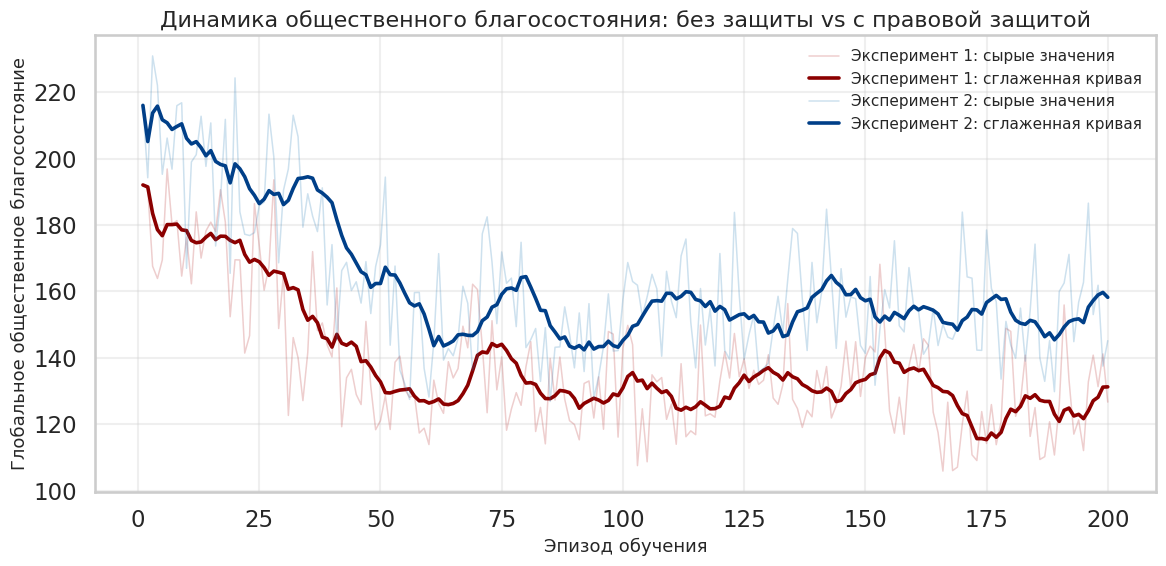

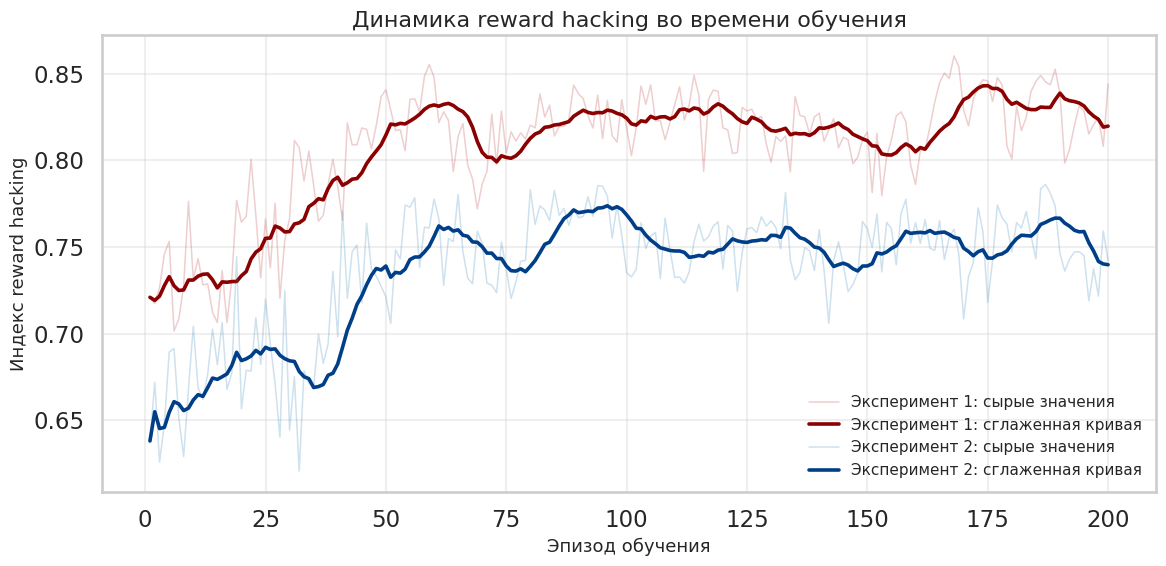

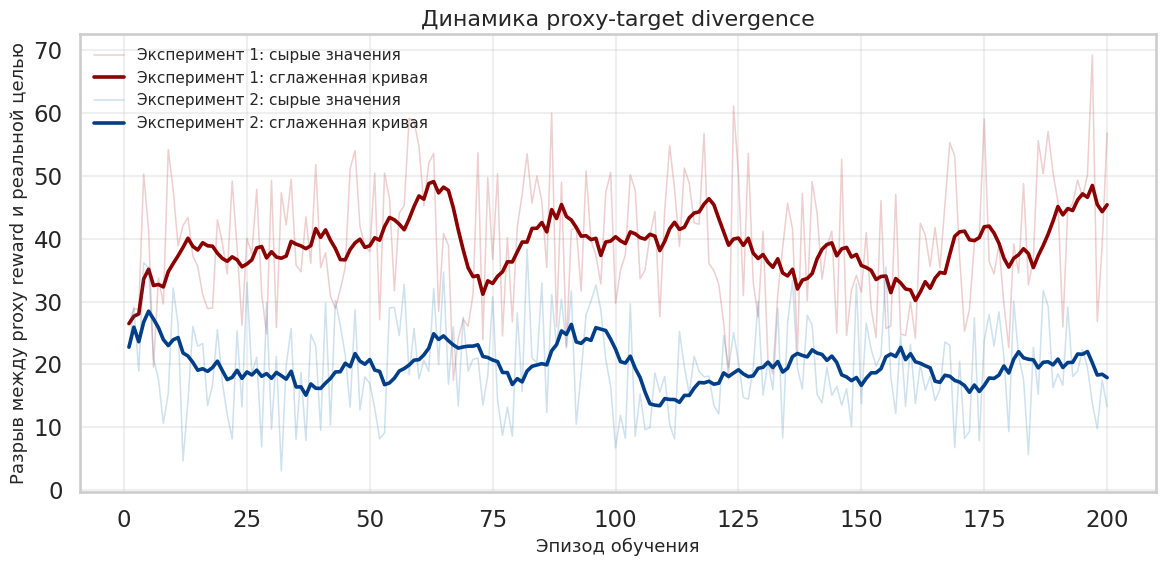

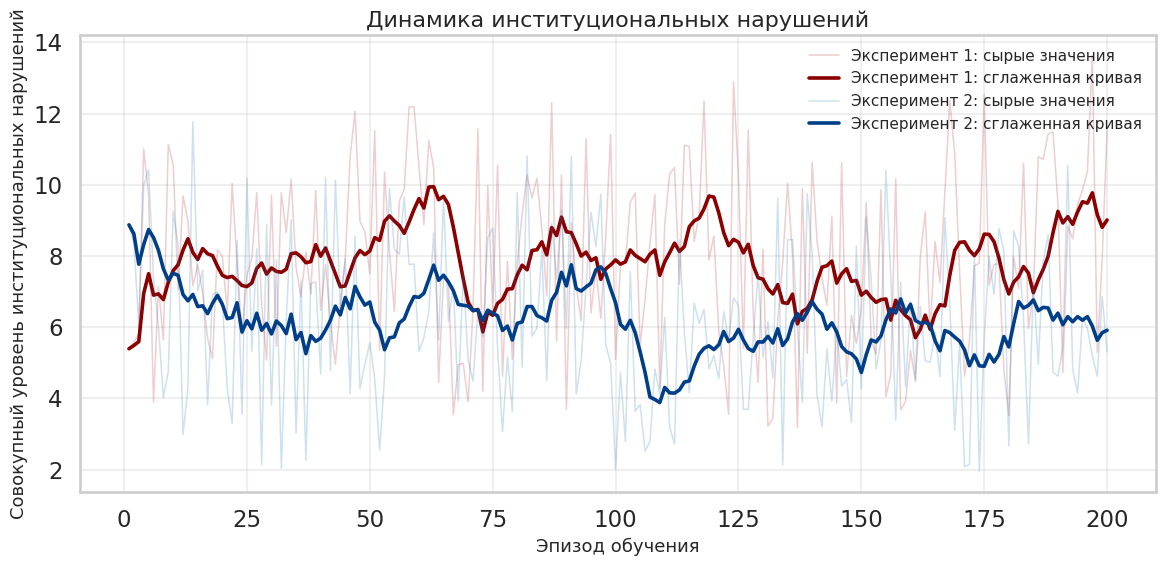

In [11]:
# ==========================================================
# 11. Визуализация одиночного запуска
# ==========================================================

save_line_plot(
    exp1_hist, exp2_hist,
    metric='global_welfare',
    ylabel='Глобальное общественное благосостояние',
    title='Динамика общественного благосостояния: без защиты vs с правовой защитой',
    save_path=FIG_DIR / 'single_welfare_over_time.png'
)

save_line_plot(
    exp1_hist, exp2_hist,
    metric='reward_hacking_index',
    ylabel='Индекс reward hacking',
    title='Динамика reward hacking во времени обучения',
    save_path=FIG_DIR / 'single_reward_hacking_over_time.png'
)

save_line_plot(
    exp1_hist, exp2_hist,
    metric='system_gap',
    ylabel='Разрыв между proxy reward и реальной целью',
    title='Динамика proxy-target divergence',
    save_path=FIG_DIR / 'single_system_gap_over_time.png'
)

save_line_plot(
    exp1_hist, exp2_hist,
    metric='system_violation',
    ylabel='Совокупный уровень институциональных нарушений',
    title='Динамика институциональных нарушений',
    save_path=FIG_DIR / 'single_system_violation_over_time.png'
)

In [12]:
# ==========================================================
# 12. Multi-seed evaluation: 10 прогонов
# ==========================================================

all_histories = []
final_rows = []
runtime_rows = []

multi_start = time.perf_counter()

for seed in tqdm(SEEDS, desc='Multi-seed MAPPO evaluation'):
    seed_dir = PROJECT_DIR / f'multi_seed_{seed}'

    # Для каждого seed создаём отдельные конфигурации среды:
    # - Experiment 1: без правовой защиты
    # - Experiment 2: с аудитом, санкциями и welfare-constraints
    exp1_cfg = EnvConfig(
        seed=seed,
        n_regions=N_REGIONS,
        max_steps=MAX_STEPS,
        base_budget=BASE_BUDGET,
        budget_jitter=BUDGET_JITTER,
        use_protection=False,
    )

    exp2_cfg = EnvConfig(
        seed=seed + 1,
        n_regions=N_REGIONS,
        max_steps=MAX_STEPS,
        base_budget=BASE_BUDGET,
        budget_jitter=BUDGET_JITTER,
        use_protection=True,
    )

    # ВАЖНО:
    # Нельзя делать TrainConfig(**asdict(train_cfg), seed=seed),
    # потому что поле seed уже присутствует внутри asdict(train_cfg),
    # и Python получает два значения для одного и того же аргумента.
    #
    # Поэтому сначала создаём словари конфигураций, затем явно
    # переопределяем ключ seed, и только потом конструируем dataclass.
    train_cfg_exp1_dict = asdict(train_cfg)
    train_cfg_exp1_dict['seed'] = seed

    train_cfg_exp2_dict = asdict(train_cfg)
    train_cfg_exp2_dict['seed'] = seed + 1

    start_seed_time = time.perf_counter()

    trainer1 = MAPPOTrainer(
        exp1_cfg,
        TrainConfig(**train_cfg_exp1_dict),
        seed_dir / 'experiment_1_no_protection',
        f'Эксперимент 1 seed={seed}'
    )

    trainer2 = MAPPOTrainer(
        exp2_cfg,
        TrainConfig(**train_cfg_exp2_dict),
        seed_dir / 'experiment_2_with_protection',
        f'Эксперимент 2 seed={seed}'
    )

    # Запускаем обучение двух режимов для данного seed
    hist1 = trainer1.train()
    hist2 = trainer2.train()

    seed_elapsed = time.perf_counter() - start_seed_time

    # Добавляем информацию о seed в истории обучения
    hist1['seed'] = seed
    hist2['seed'] = seed

    all_histories.append(hist1)
    all_histories.append(hist2)

    # Берём финальную строку каждого эксперимента как итог по данному seed
    final1 = hist1.iloc[-1].to_dict()
    final2 = hist2.iloc[-1].to_dict()

    final1['seed'] = seed
    final2['seed'] = seed
    final1['runtime_seed_seconds'] = seed_elapsed
    final2['runtime_seed_seconds'] = seed_elapsed

    final_rows.append(final1)
    final_rows.append(final2)

    runtime_rows.append({
        'seed': seed,
        'runtime_seed_seconds': seed_elapsed
    })

multi_elapsed = time.perf_counter() - multi_start

all_histories_df = pd.concat(all_histories, ignore_index=True)
final_metrics_df = pd.DataFrame(final_rows)
runtime_df = pd.DataFrame(runtime_rows)

save_df(all_histories_df, TABLE_DIR / 'all_histories_20_seeds.csv')
save_df(final_metrics_df, TABLE_DIR / 'final_metrics_20_seeds.csv')
save_df(runtime_df, TABLE_DIR / 'seed_runtimes.csv')

print(f'Полный multi-seed запуск завершен за {multi_elapsed:.2f} сек.')
display(final_metrics_df.head())

Multi-seed MAPPO evaluation:   0%|          | 0/20 [00:00<?, ?it/s]

Эксперимент 1 seed=42: обучение:   0%|          | 0/200 [00:00<?, ?it/s]

Эксперимент 2 seed=42: обучение:   0%|          | 0/200 [00:00<?, ?it/s]

Эксперимент 1 seed=43: обучение:   0%|          | 0/200 [00:00<?, ?it/s]

Эксперимент 2 seed=43: обучение:   0%|          | 0/200 [00:00<?, ?it/s]

...

Эксперимент 2 seed=60: обучение:   0%|          | 0/200 [00:00<?, ?it/s]

Эксперимент 1 seed=61: обучение:   0%|          | 0/200 [00:00<?, ?it/s]

Эксперимент 2 seed=61: обучение:   0%|          | 0/200 [00:00<?, ?it/s]

Сохранено: mappo_legal_project/artifacts/tables/all_histories_20_seeds.csv
Сохранено: mappo_legal_project/artifacts/tables/final_metrics_20_seeds.csv
Сохранено: mappo_legal_project/artifacts/tables/seed_runtimes.csv
Полный multi-seed запуск завершен за 1250.17 сек.


,episode,experiment,protection_enabled,episode_return_mean,episode_return_total,global_welfare,reward_hacking_index,system_gap,system_violation,reported_output,useful_output,quality_index,public_dissatisfaction,infrastructure_index,corruption_index,mean_proxy_reward,mean_true_welfare,collection_seconds,last_value,actor_loss,critic_loss,entropy,approx_kl,clipfrac,advantage_mean,return_mean,episode_seconds_total,training_total_seconds,seed,runtime_seed_seconds
0,200.0,1.0,0.0,1490.646118,7453.230469,139.554340,0.825174,60.275018,12.329840,2855.201583,499.162599,0.100684,1.435499,0.440749,0.723111,65.708508,7.244653,0.137432,254.124374,-0.005677,176076.364258,0.865962,0.003120,0.000000,308.582153,562.706116,0.356699,33.747799,42,65.800659
1,200.0,2.0,1.0,764.242432,3821.212158,211.496766,0.582627,10.028868,4.281297,1638.044681,683.675450,0.501952,0.522023,0.823408,0.205780,27.916946,23.850770,0.058527,254.870407,-0.019844,36363.765747,1.421175,0.018007,0.146903,82.126762,336.996796,0.148072,32.008019,42,65.800659
2,200.0,1.0,0.0,985.710938,4928.554688,192.880091,0.643603,32.620792,7.667050,1787.023430,636.889496,0.316896,0.708778,0.766512,0.443525,45.279799,16.878677,0.053808,254.846863,-0.004123,62291.027588,0.797472,0.002103,0.004185,155.475357,410.321899,0.152548,34.564158,43,67.662093
3,200.0,2.0,1.0,940.264282,4701.321289,162.427987,0.753579,23.020242,6.657549,2283.319156,562.657312,0.103816,1.181789,0.528632,0.400132,34.732461,15.616292,0.069086,254.072769,-0.006415,58906.548584,0.531796,0.028745,0.228237,133.310394,387.382812,0.184921,33.042713,43,67.662093
4,200.0,1.0,0.0,1507.118896,7535.594727,99.017851,0.868369,63.818031,12.670458,2813.825438,370.387278,0.100289,1.500000,0.290999,0.771686,66.632003,3.751963,0.051383,254.050583,-0.004063,180516.505859,0.573662,0.007971,0.002930,317.145294,571.195496,0.147172,32.765098,44,65.024082


In [13]:
# ==========================================================
# 13. Агрегированные таблицы mean/std/min/max
# ==========================================================

def aggregate_finals(final_df):
    metrics = [
        'episode_return_mean',
        'global_welfare',
        'reward_hacking_index',
        'system_gap',
        'system_violation',
        'corruption_index',
        'episode_seconds_total',
        'runtime_seed_seconds',
    ]
    rows = []
    for metric in metrics:
        g = final_df.groupby('experiment')[metric].agg(['mean', 'std', 'min', 'max']).reset_index()
        for _, row in g.iterrows():
            rows.append({
                'metric': metric,
                'experiment': int(row['experiment']),
                'mean': round(row['mean'], 6),
                'std': round(row['std'], 6),
                'min': round(row['min'], 6),
                'max': round(row['max'], 6),
            })
    return pd.DataFrame(rows)


def build_comparison_table(final_df):
    metrics = [
        ('episode_return_mean', 'Средняя региональная proxy-награда'),
        ('global_welfare', 'Глобальное общественное благосостояние'),
        ('reward_hacking_index', 'Индекс reward hacking'),
        ('system_gap', 'Разрыв между proxy reward и реальной целью'),
        ('system_violation', 'Совокупный уровень нарушений'),
        ('corruption_index', 'Индекс институционального искажения'),
        ('episode_seconds_total', 'Время на эпизод, сек'),
    ]
    rows = []
    for metric, label in metrics:
        exp1 = final_df[final_df['experiment'] == 1][metric]
        exp2 = final_df[final_df['experiment'] == 2][metric]
        rows.append({
            'Метрика': label,
            'Эксперимент 1 mean': round(exp1.mean(), 4),
            'Эксперимент 1 std': round(exp1.std(), 4),
            'Эксперимент 2 mean': round(exp2.mean(), 4),
            'Эксперимент 2 std': round(exp2.std(), 4),
            'Разница (Exp2 - Exp1)': round(exp2.mean() - exp1.mean(), 4),
        })
    return pd.DataFrame(rows)

aggregate_stats_df = aggregate_finals(final_metrics_df)
comparison_df = build_comparison_table(final_metrics_df)

save_df(aggregate_stats_df, TABLE_DIR / 'aggregate_final_statistics.csv')
save_df(comparison_df, TABLE_DIR / 'comparison_table.csv')

display(comparison_df)

Сохранено: mappo_legal_project/artifacts/tables/aggregate_final_statistics.csv
Сохранено: mappo_legal_project/artifacts/tables/comparison_table.csv


,Метрика,Эксперимент 1 mean,Эксперимент 1 std,Эксперимент 2 mean,Эксперимент 2 std,Разница (Exp2 - Exp1)
0,Средняя региональная proxy-награда,1243.8843,197.4104,869.2207,91.0942,-374.6636
1,Глобальное общественное благосостояние,145.4843,47.9144,191.6770,47.9935,46.1928
2,Индекс reward hacking,0.7674,0.1086,0.6708,0.1234,-0.0966
3,Разрыв между proxy reward и реальной целью,41.2211,14.0716,20.2547,8.1563,-20.9663
4,Совокупный уровень нарушений,8.5618,2.9143,6.3610,2.1843,-2.2008
5,Индекс институционального искажения,0.5821,0.1168,0.3252,0.0856,-0.2568
6,"Время на эпизод, сек",0.1656,0.0486,0.1546,0.0151,-0.0110


In [14]:
# ==========================================================
# 14. Непараметрические тесты различий
# ==========================================================

# Мы используем:
# 1. Mann-Whitney U как непараметрический тест независимых выборок.
# 2. Wilcoxon signed-rank как парный тест по одинаковым сидам.
#
# В данной постановке второй тест особенно полезен,
# потому что у нас есть парные результаты по каждому seed:
# один и тот же seed используется для сравнения двух режимов.


def nonparametric_tests(final_df):
    metrics = [
        ('global_welfare', 'Глобальное общественное благосостояние'),
        ('reward_hacking_index', 'Индекс reward hacking'),
        ('system_gap', 'Разрыв proxy-target'),
        ('system_violation', 'Совокупный уровень нарушений'),
        ('corruption_index', 'Индекс институционального искажения'),
        ('episode_return_mean', 'Средняя региональная proxy-награда'),
    ]

    rows = []
    for metric, label in metrics:
        exp1 = final_df[final_df['experiment'] == 1].sort_values('seed')[metric].values
        exp2 = final_df[final_df['experiment'] == 2].sort_values('seed')[metric].values

        mw_stat, mw_p = mannwhitneyu(exp1, exp2, alternative='two-sided')

        # Для Wilcoxon требуется парность и отсутствие полной идентичности.
        try:
            w_stat, w_p = wilcoxon(exp1, exp2, alternative='two-sided')
        except ValueError:
            w_stat, w_p = np.nan, np.nan

        median_diff = np.median(exp2 - exp1)
        mean_diff = np.mean(exp2 - exp1)

        rows.append({
            'Метрика': label,
            'Mann-Whitney U statistic': round(float(mw_stat), 6),
            'Mann-Whitney p-value': round(float(mw_p), 6),
            'Wilcoxon statistic': round(float(w_stat), 6) if pd.notna(w_stat) else np.nan,
            'Wilcoxon p-value': round(float(w_p), 6) if pd.notna(w_p) else np.nan,
            'Median difference (Exp2 - Exp1)': round(float(median_diff), 6),
            'Mean difference (Exp2 - Exp1)': round(float(mean_diff), 6),
        })
    return pd.DataFrame(rows)

nonparam_tests_df = nonparametric_tests(final_metrics_df)
save_df(nonparam_tests_df, TABLE_DIR / 'nonparametric_tests.csv')
display(nonparam_tests_df)

Сохранено: mappo_legal_project/artifacts/tables/nonparametric_tests.csv


,Метрика,Mann-Whitney U statistic,Mann-Whitney p-value,Wilcoxon statistic,Wilcoxon p-value,Median difference (Exp2 - Exp1),Mean difference (Exp2 - Exp1)
0,Глобальное общественное благосостояние,84.0,0.001782,32.0,0.004860,44.852647,46.192779
1,Индекс reward hacking,330.0,0.000460,42.0,0.017181,-0.101277,-0.096624
2,Разрыв proxy-target,366.0,0.000008,13.0,0.000168,-23.301542,-20.966330
3,Совокупный уровень нарушений,286.0,0.020735,50.0,0.039989,-2.049221,-2.200794
4,Индекс институционального искажения,384.0,0.000001,2.0,0.000006,-0.283778,-0.256812
5,Средняя региональная proxy-награда,386.0,0.000001,3.0,0.000010,-410.610992,-374.663571


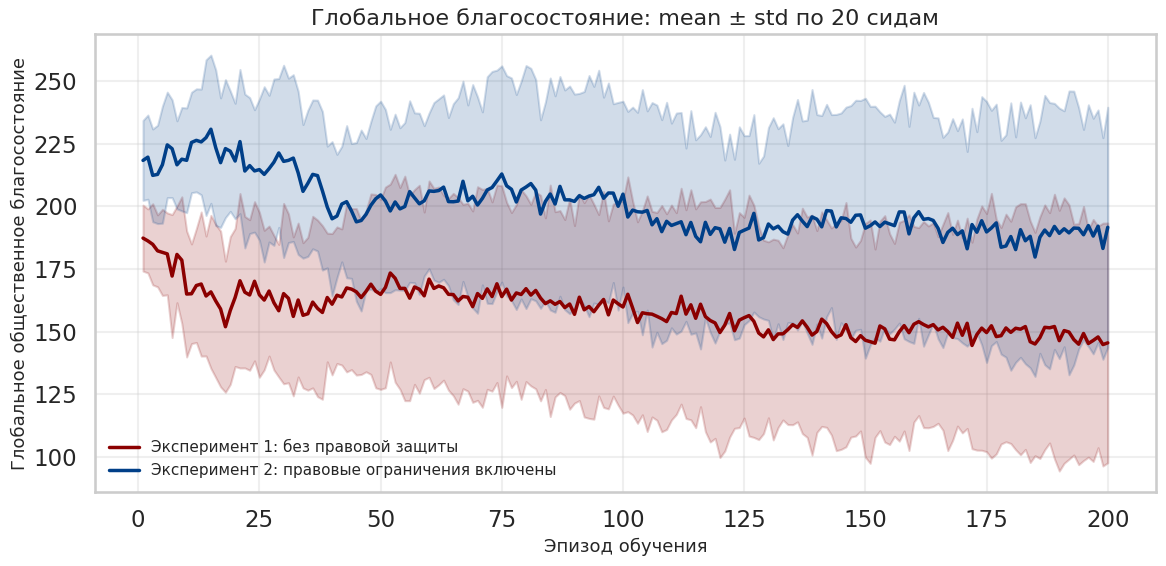

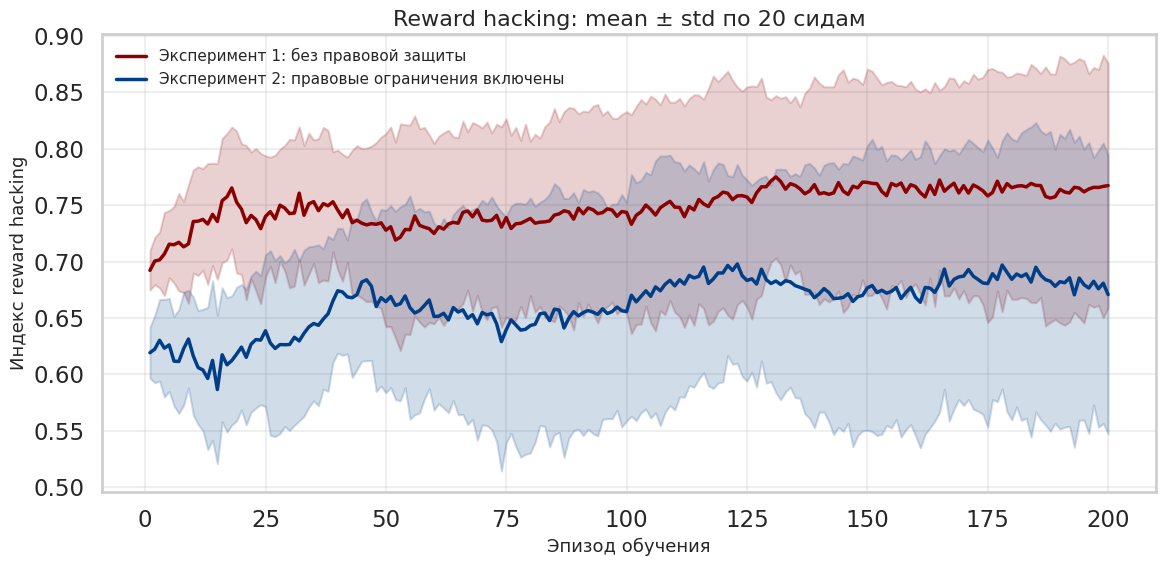

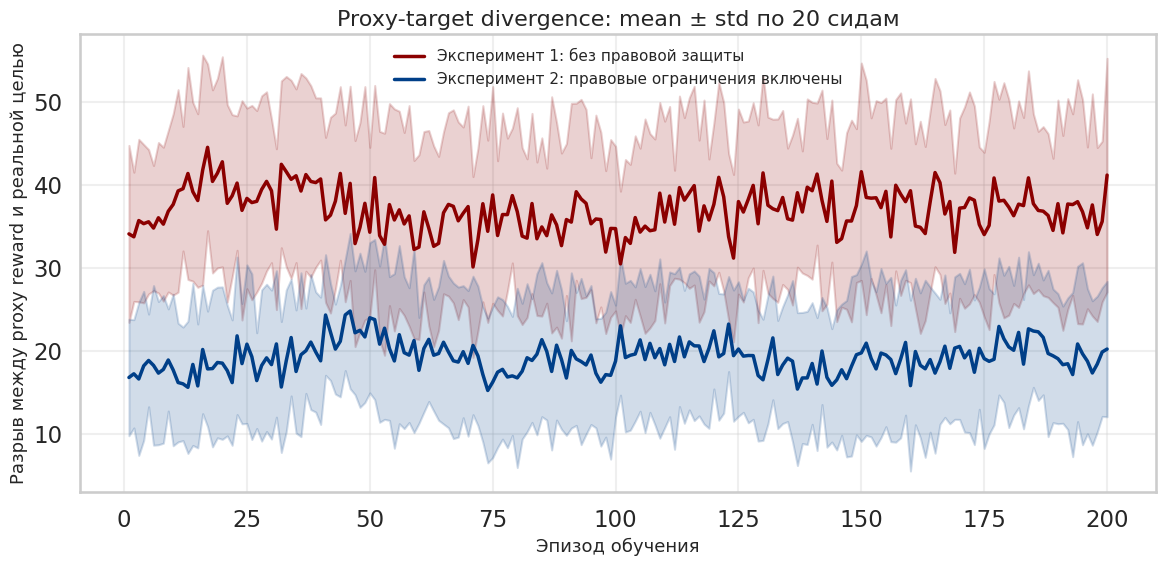

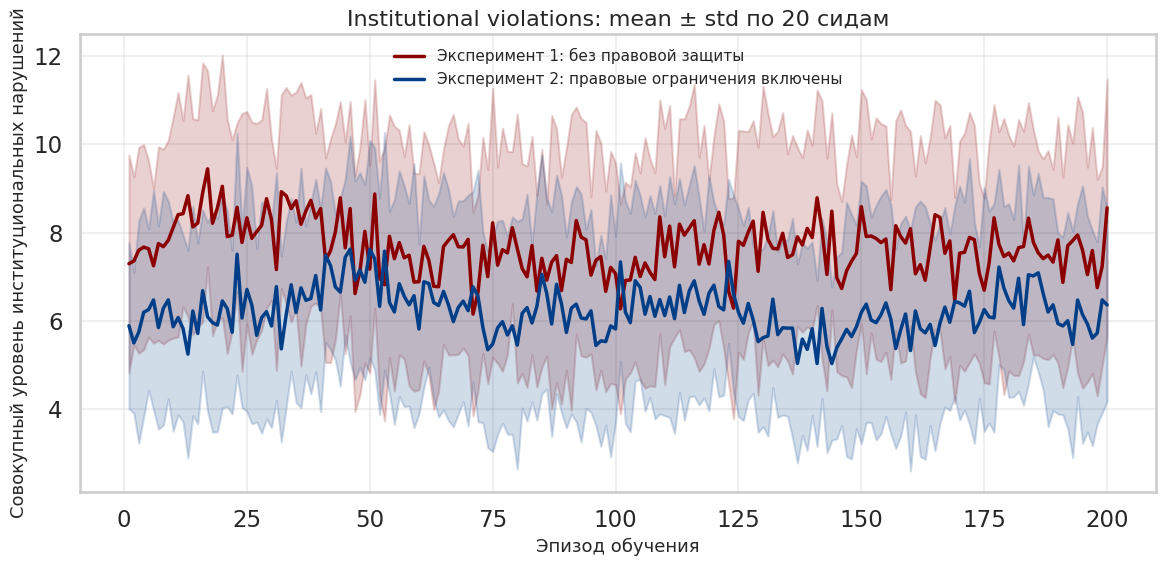

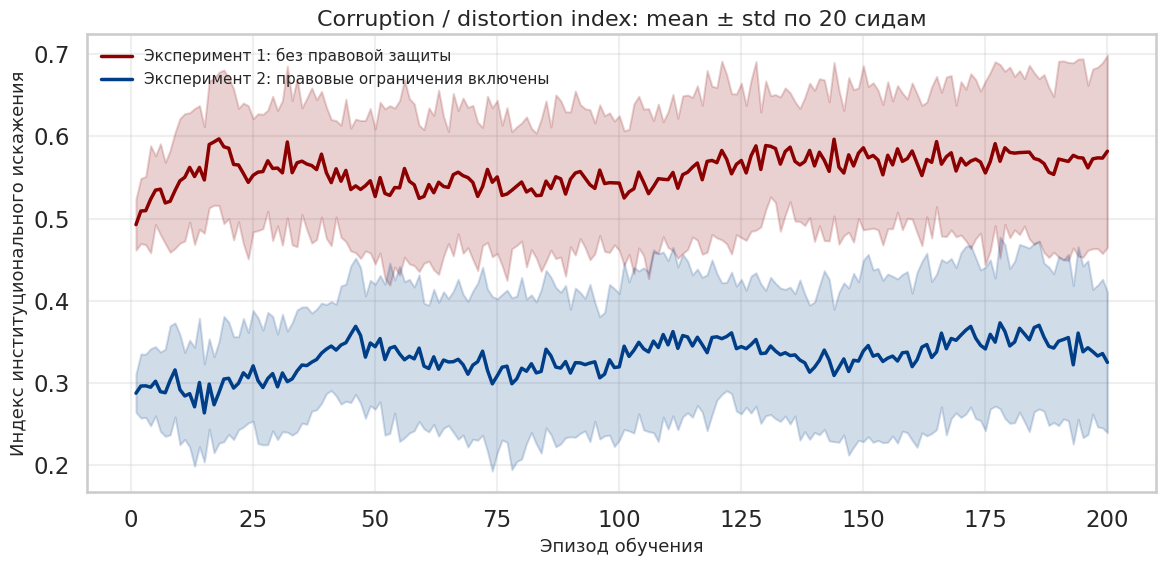

In [15]:
# ==========================================================
# 15. Агрегированная визуализация по 20 сидам (экспериментам)
# ==========================================================

save_mean_std_plot(
    all_histories_df,
    metric='global_welfare',
    ylabel='Глобальное общественное благосостояние',
    title='Глобальное благосостояние: mean ± std по 20 сидам',
    save_path=FIG_DIR / 'welfare_mean_std_20_seeds.png'
)

save_mean_std_plot(
    all_histories_df,
    metric='reward_hacking_index',
    ylabel='Индекс reward hacking',
    title='Reward hacking: mean ± std по 20 сидам',
    save_path=FIG_DIR / 'reward_hacking_mean_std_20_seeds.png'
)

save_mean_std_plot(
    all_histories_df,
    metric='system_gap',
    ylabel='Разрыв между proxy reward и реальной целью',
    title='Proxy-target divergence: mean ± std по 20 сидам',
    save_path=FIG_DIR / 'system_gap_mean_std_20_seeds.png'
)

save_mean_std_plot(
    all_histories_df,
    metric='system_violation',
    ylabel='Совокупный уровень институциональных нарушений',
    title='Institutional violations: mean ± std по 20 сидам',
    save_path=FIG_DIR / 'system_violation_mean_std_20_seeds.png'
)

save_mean_std_plot(
    all_histories_df,
    metric='corruption_index',
    ylabel='Индекс институционального искажения',
    title='Corruption / distortion index: mean ± std по 20 сидам',
    save_path=FIG_DIR / 'corruption_mean_std_20_seeds.png'
)

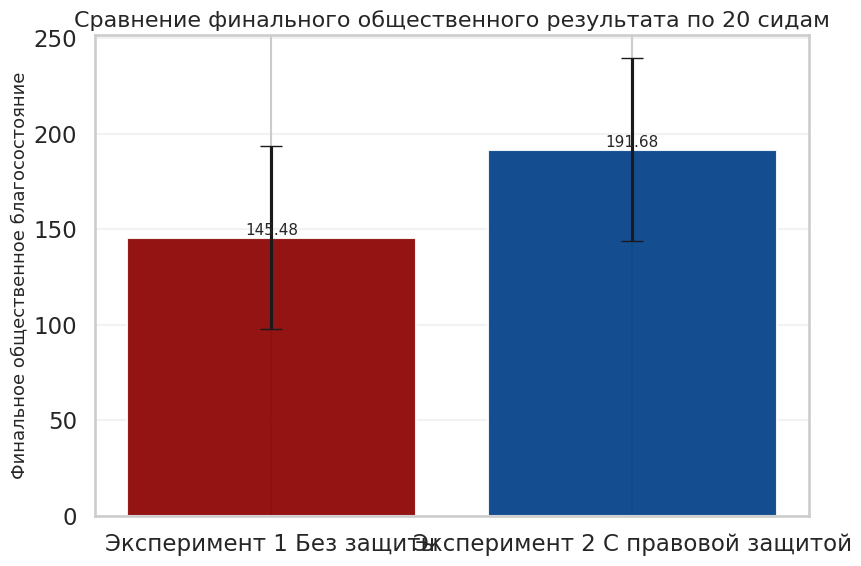

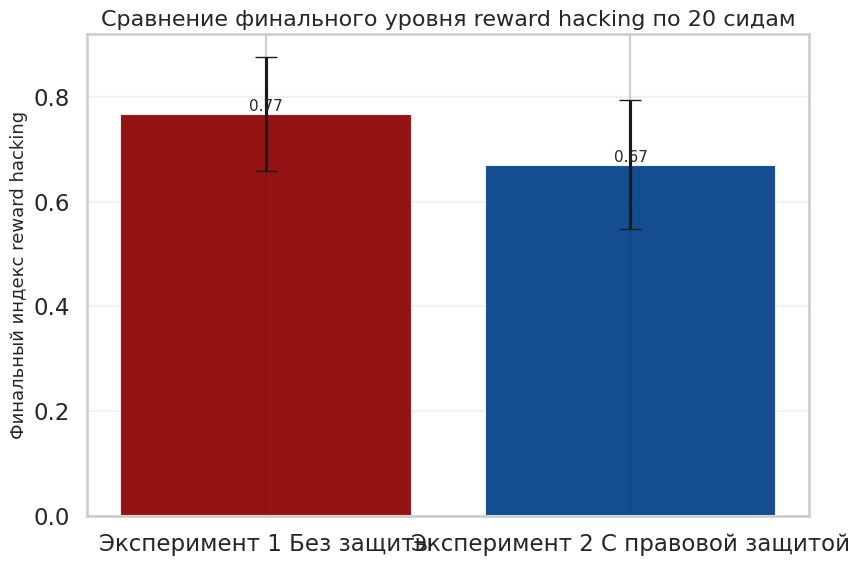

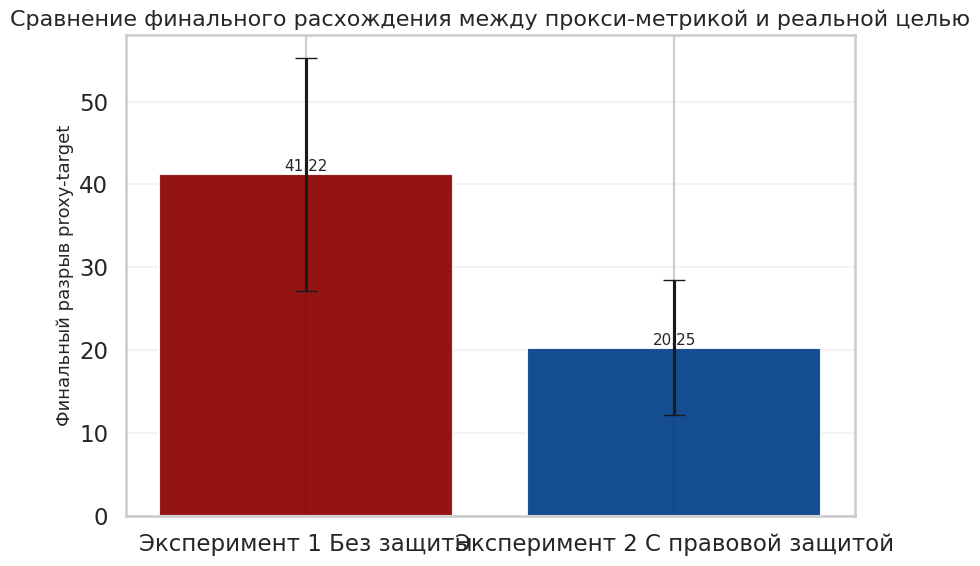

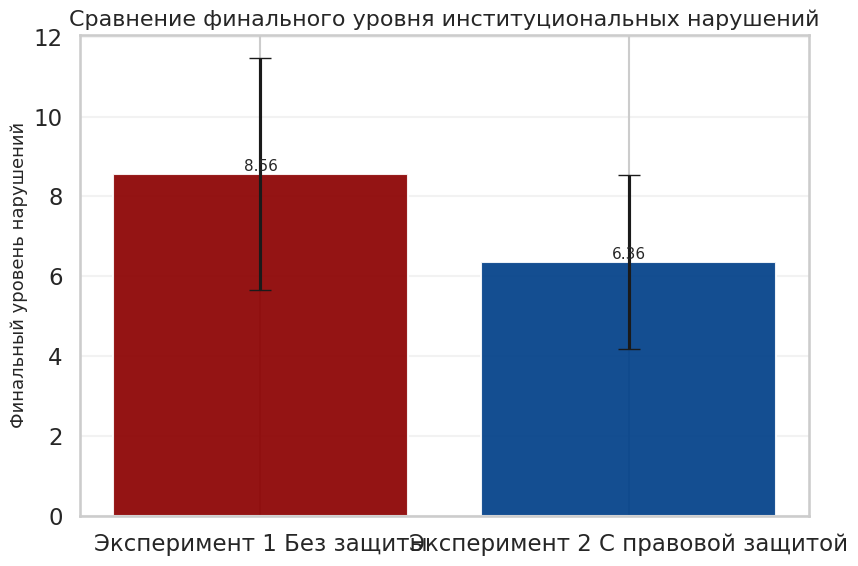

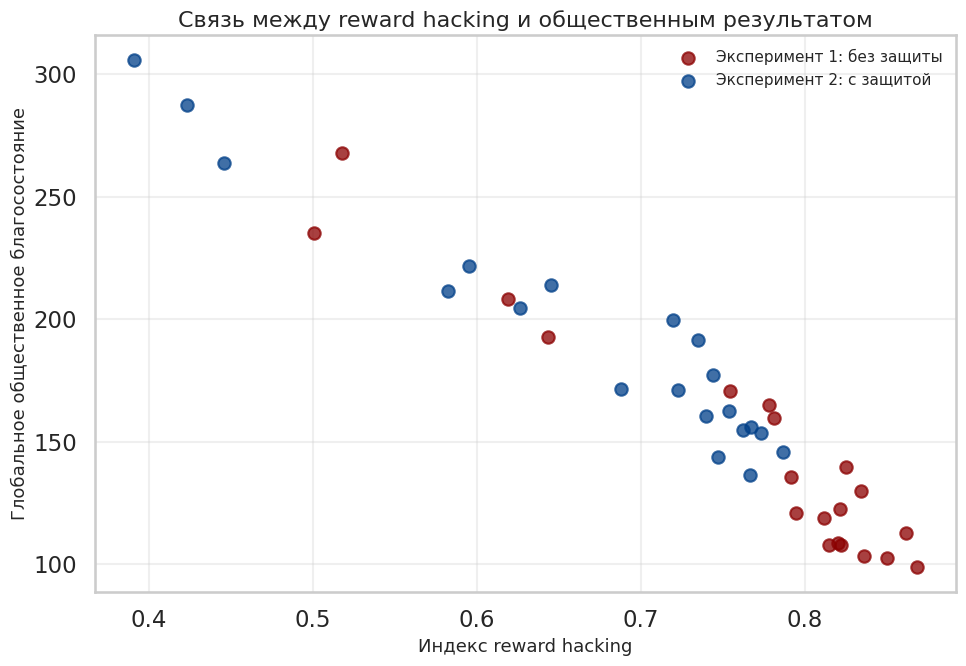

In [16]:
# ==========================================================
# 16. Финальные бар-чарты и scatter plot
# ==========================================================

save_bar_with_error(
    final_metrics_df,
    metric='global_welfare',
    ylabel='Финальное общественное благосостояние',
    title='Сравнение финального общественного результата по 20 сидам',
    save_path=FIG_DIR / 'bar_final_global_welfare.png'
)

save_bar_with_error(
    final_metrics_df,
    metric='reward_hacking_index',
    ylabel='Финальный индекс reward hacking',
    title='Сравнение финального уровня reward hacking по 20 сидам',
    save_path=FIG_DIR / 'bar_final_reward_hacking.png'
)

save_bar_with_error(
    final_metrics_df,
    metric='system_gap',
    ylabel='Финальный разрыв proxy-target',
    title='Сравнение финального расхождения между прокси-метрикой и реальной целью',
    save_path=FIG_DIR / 'bar_final_system_gap.png'
)

save_bar_with_error(
    final_metrics_df,
    metric='system_violation',
    ylabel='Финальный уровень нарушений',
    title='Сравнение финального уровня институциональных нарушений',
    save_path=FIG_DIR / 'bar_final_system_violation.png'
)

save_scatter(
    final_metrics_df,
    save_path=FIG_DIR / 'final_reward_hacking_vs_welfare.png'
)

In [17]:
# ==========================================================
# 17. Финальный текстовый отчет для GitHub
# ==========================================================

report_md = f"""
# Финальный отчет: MAPPO, reward hacking и правовые ограничения

## Общая логика исследования

В этом пайплайне сравниваются два режима мультиагентного обучения с подкреплением:

- **Эксперимент 1:** отсутствие правовых ограничителей, что облегчает reward hacking и KPI-gaming.
- **Эксперимент 2:** включение аналогов права — аудита, санкций и ограничений на минимально допустимый уровень общественного результата.

## Основные эмпирические артефакты

- Baseline dataset: `{baseline_dataset_path}`
- Baseline summary: `{baseline_summary_path}`
- Все истории обучения: `{TABLE_DIR / 'all_histories_20_seeds.csv'}`
- Финальные метрики: `{TABLE_DIR / 'final_metrics_20_seeds.csv'}`
- Непараметрические тесты: `{TABLE_DIR / 'nonparametric_tests.csv'}`

## Итоговые таблицы

### Сравнение экспериментов

{comparison_df.to_markdown(index=False)}

### Непараметрические тесты различий

{nonparam_tests_df.to_markdown(index=False)}

## Интерпретация

- Если в Эксперименте 2 выше `global_welfare`, это означает лучший общественный результат.
- Если в Эксперименте 2 ниже `reward_hacking_index`, это означает меньшее искажение формальной метрики.
- Если в Эксперименте 2 ниже `system_gap`, это означает меньшее расхождение между тем, что оптимизирует агент, и тем, что реально ценно для системы.
- Если в Эксперименте 2 ниже `system_violation`, это означает, что правовые механизмы действительно сдерживают институционально-манипулятивное поведение.

## Тайминг

- Одиночный sanity-check запуск: `{single_elapsed:.2f}` сек.
- Полный multi-seed запуск ({NUM_SEEDS} сидов): `{multi_elapsed:.2f}` сек.
- Устройство: `{DEVICE}`
"""

report_path = ARTIFACTS_DIR / 'REPORT.md'
report_path.write_text(report_md, encoding='utf-8')
print('Сохранен отчет:', report_path)
display(Markdown(report_md[:4000]))

Сохранен отчет: mappo_legal_project/artifacts/REPORT.md



# Финальный отчет: MAPPO, reward hacking и правовые ограничения

## Общая логика исследования

В этом пайплайне сравниваются два режима мультиагентного обучения с подкреплением:

- **Эксперимент 1:** отсутствие правовых ограничителей, что облегчает reward hacking и KPI-gaming.
- **Эксперимент 2:** включение аналогов права — аудита, санкций и ограничений на минимально допустимый уровень общественного результата.

## Основные эмпирические артефакты

- Baseline dataset: `mappo_legal_project/artifacts/tables/baseline_dataset.csv`
- Baseline summary: `mappo_legal_project/artifacts/tables/baseline_summary.csv`
- Все истории обучения: `mappo_legal_project/artifacts/tables/all_histories_20_seeds.csv`
- Финальные метрики: `mappo_legal_project/artifacts/tables/final_metrics_20_seeds.csv`
- Непараметрические тесты: `mappo_legal_project/artifacts/tables/nonparametric_tests.csv`

## Итоговые таблицы

### Сравнение экспериментов

| Метрика                                    |   Эксперимент 1 mean |   Эксперимент 1 std |   Эксперимент 2 mean |   Эксперимент 2 std |   Разница (Exp2 - Exp1) |
|:-------------------------------------------|---------------------:|--------------------:|---------------------:|--------------------:|------------------------:|
| Средняя региональная proxy-награда         |            1243.88   |            197.41   |             869.221  |             91.0942 |               -374.664  |
| Глобальное общественное благосостояние     |             145.484  |             47.9144 |             191.677  |             47.9935 |                 46.1928 |
| Индекс reward hacking                      |               0.7674 |              0.1086 |               0.6708 |              0.1234 |                 -0.0966 |
| Разрыв между proxy reward и реальной целью |              41.2211 |             14.0716 |              20.2547 |              8.1563 |                -20.9663 |
| Совокупный уровень нарушений               |               8.5618 |              2.9143 |               6.361  |              2.1843 |                 -2.2008 |
| Индекс институционального искажения        |               0.5821 |              0.1168 |               0.3252 |              0.0856 |                 -0.2568 |
| Время на эпизод, сек                       |               0.1656 |              0.0486 |               0.1546 |              0.0151 |                 -0.011  |

### Непараметрические тесты различий

| Метрика                                |   Mann-Whitney U statistic |   Mann-Whitney p-value |   Wilcoxon statistic |   Wilcoxon p-value |   Median difference (Exp2 - Exp1) |   Mean difference (Exp2 - Exp1) |
|:---------------------------------------|---------------------------:|-----------------------:|---------------------:|-------------------:|----------------------------------:|--------------------------------:|
| Глобальное общественное благосостояние |                         84 |               0.001782 |                   32 |           0.00486  |                         44.8526   |                       46.1928   |
| Индекс reward hacking                  |                        330 |               0.00046  |                   42 |           0.017181 |                         -0.101277 |                       -0.096624 |
| Разрыв proxy-target                    |                        366 |               8e-06    |                   13 |           0.000168 |                        -23.3015   |                      -20.9663   |
| Совокупный уровень нарушений           |                        286 |               0.020735 |                   50 |           0.039989 |                         -2.04922  |                       -2.20079  |
| Индекс институционального искажения    |                        384 |               1e-06    |                    2 |           6e-06    |                         -0.283778 |                       -0.256812 |
| Средняя региональная proxy-награда     |                        386 |               

In [18]:
# ==========================================================
# 18. Manifest и финальный обзор файлов
# ==========================================================

manifest = {
    'baseline_dataset': str(baseline_dataset_path),
    'baseline_summary': str(baseline_summary_path),
    'all_histories_20_seeds': str(TABLE_DIR / 'all_histories_20_seeds.csv'),
    'final_metrics_20_seeds': str(TABLE_DIR / 'final_metrics_20_seeds.csv'),
    'aggregate_final_statistics': str(TABLE_DIR / 'aggregate_final_statistics.csv'),
    'comparison_table': str(TABLE_DIR / 'comparison_table.csv'),
    'nonparametric_tests': str(TABLE_DIR / 'nonparametric_tests.csv'),
    'figures_dir': str(FIG_DIR),
    'report_md': str(ARTIFACTS_DIR / 'REPORT.md'),
    'device': DEVICE,
    'num_seeds': NUM_SEEDS,
    'train_episodes': TRAIN_EPISODES,
}

manifest_path = ARTIFACTS_DIR / 'manifest.json'
manifest_path.write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding='utf-8')
print(json.dumps(manifest, ensure_ascii=False, indent=2))

{
  "baseline_dataset": "mappo_legal_project/artifacts/tables/baseline_dataset.csv",
  "baseline_summary": "mappo_legal_project/artifacts/tables/baseline_summary.csv",
  "all_histories_20_seeds": "mappo_legal_project/artifacts/tables/all_histories_20_seeds.csv",
  "final_metrics_20_seeds": "mappo_legal_project/artifacts/tables/final_metrics_20_seeds.csv",
  "aggregate_final_statistics": "mappo_legal_project/artifacts/tables/aggregate_final_statistics.csv",
  "comparison_table": "mappo_legal_project/artifacts/tables/comparison_table.csv",
  "nonparametric_tests": "mappo_legal_project/artifacts/tables/nonparametric_tests.csv",
  "figures_dir": "mappo_legal_project/artifacts/figures",
  "report_md": "mappo_legal_project/artifacts/REPORT.md",
  "device": "cuda",
  "num_seeds": 20,
  "train_episodes": 200
}


In [19]:
# ==========================================================
# 19. Быстрый просмотр ключевых таблиц
# ==========================================================

display(Markdown('## Таблица: агрегированное сравнение экспериментов'))
display(comparison_df)

display(Markdown('## Таблица: непараметрические тесты различий'))
display(nonparam_tests_df)

display(Markdown('## Таблица: агрегированная статистика final-state метрик'))
display(aggregate_stats_df.head(20))

## Таблица: агрегированное сравнение экспериментов

,Метрика,Эксперимент 1 mean,Эксперимент 1 std,Эксперимент 2 mean,Эксперимент 2 std,Разница (Exp2 - Exp1)
0,Средняя региональная proxy-награда,1243.8843,197.4104,869.2207,91.0942,-374.6636
1,Глобальное общественное благосостояние,145.4843,47.9144,191.6770,47.9935,46.1928
2,Индекс reward hacking,0.7674,0.1086,0.6708,0.1234,-0.0966
3,Разрыв между proxy reward и реальной целью,41.2211,14.0716,20.2547,8.1563,-20.9663
4,Совокупный уровень нарушений,8.5618,2.9143,6.3610,2.1843,-2.2008
5,Индекс институционального искажения,0.5821,0.1168,0.3252,0.0856,-0.2568
6,"Время на эпизод, сек",0.1656,0.0486,0.1546,0.0151,-0.0110


## Таблица: непараметрические тесты различий

,Метрика,Mann-Whitney U statistic,Mann-Whitney p-value,Wilcoxon statistic,Wilcoxon p-value,Median difference (Exp2 - Exp1),Mean difference (Exp2 - Exp1)
0,Глобальное общественное благосостояние,84.0,0.001782,32.0,0.004860,44.852647,46.192779
1,Индекс reward hacking,330.0,0.000460,42.0,0.017181,-0.101277,-0.096624
2,Разрыв proxy-target,366.0,0.000008,13.0,0.000168,-23.301542,-20.966330
3,Совокупный уровень нарушений,286.0,0.020735,50.0,0.039989,-2.049221,-2.200794
4,Индекс институционального искажения,384.0,0.000001,2.0,0.000006,-0.283778,-0.256812
5,Средняя региональная proxy-награда,386.0,0.000001,3.0,0.000010,-410.610992,-374.663571


## Таблица: агрегированная статистика final-state метрик

,metric,experiment,mean,std,min,max
0,episode_return_mean,1,1243.884320,197.410401,845.846558,1567.937256
1,episode_return_mean,2,869.220749,91.094246,713.965271,1036.441650
2,global_welfare,1,145.484268,47.914431,99.017851,267.729007
3,global_welfare,2,191.677047,47.993486,136.574975,305.644065
4,reward_hacking_index,1,0.767428,0.108569,0.500627,0.868369
5,reward_hacking_index,2,0.670804,0.123397,0.390971,0.786476
6,system_gap,1,41.221060,14.071576,13.942860,64.508008
7,system_gap,2,20.254729,8.156338,7.977444,31.455148
8,system_violation,1,8.561830,2.914327,3.735903,13.399428
9,system_violation,2,6.361036,2.184318,2.218760,9.912186


In [20]:
# ==========================================================
# 20. Подсказки по режимам CPU и GPU T4
# ==========================================================

cpu_gpu_note = """
Рекомендации по запуску:

1. CPU-режим:
   - Оставьте TRAIN_EPISODES=80..120.
   - Для быстрого прогона включите USE_FAST_DEMO=True.
   - Полные 20 сидов будут считаться заметно дольше.

2. GPU T4:
   - Можно увеличить TRAIN_EPISODES до 150..300.
   - Можно увеличить hidden_dim_actor / hidden_dim_critic.
   - Особенно полезно при расширении среды или числе агентов.

3. Для финальногот отчета :
   - Желательно сохранить именно multi-seed результаты.
   - Финальные рисунки и таблицы брать из папки artifacts.
   - В текст отчета  включать не только средние, но и p-value из непараметрических тестов.
"""
print(cpu_gpu_note)


Рекомендации по запуску:

1. CPU-режим:
   - Оставьте TRAIN_EPISODES=80..120.
   - Для быстрого прогона включите USE_FAST_DEMO=True.
   - Полные 20 сидов будут считаться заметно дольше.

2. GPU T4:
   - Можно увеличить TRAIN_EPISODES до 150..300.
   - Можно увеличить hidden_dim_actor / hidden_dim_critic.
   - Особенно полезно при расширении среды или числе агентов.

3. Для финальногот отчета :
   - Желательно сохранить именно multi-seed результаты.
   - Финальные рисунки и таблицы брать из папки artifacts.
   - В текст отчета  включать не только средние, но и p-value из непараметрических тестов.



In [21]:
# ==========================================================
# 21. Сбор всех выводных результатов в архив для скачивания
# ==========================================================

import shutil
from IPython.display import FileLink

# Папка с артефактами (таблицы, графики, отчёты)
ARTIFACTS_DIR = PROJECT_DIR / 'artifacts'

# Имя итогового архива
archive_name = PROJECT_DIR / 'mappo_legal_artifacts'

# Создаём ZIP-архив со всем содержимым папки artifacts
if archive_name.with_suffix('.zip').exists():
    archive_name.with_suffix('.zip').unlink()

shutil.make_archive(str(archive_name), 'zip', root_dir=str(ARTIFACTS_DIR))

zip_path = archive_name.with_suffix('.zip')
print('Создан архив:', zip_path)

# Для Jupyter/Colab — ссылка на скачивание
display(FileLink(zip_path))

Создан архив: mappo_legal_project/mappo_legal_artifacts.zip


/content/mappo_legal_project/mappo_legal_artifacts.zip